In [ ]:
using IonSim
using QuantumOptics
using PyPlot

function plot_wigner(final_state)
    rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(20)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
end


function SDF_apply_with_alpha(angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0)
        
        red_angle = -angle
        blue_angle = angle
    

    if (cat_state)
        # println("Preparing cat state superposi/tion...")
        red_angle = (π - 2*angle ) /2
        blue_angle = red_angle + 2 *angle
    end
    
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 20
    mode_z.shape = [21]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e4 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

    # ---------------------------------------------------------
    # NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    c = 2.99792458e8           

    # 1. Calculate Lamb-Dicke Parameter (η) dynamically
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    # 2. Hijack IonSim's internal matrix element calculator
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    # Feed the dummy laser into the exact internal physics engine
    # (Note: Unexported internal functions need the module prefix 'IonSim.')
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    # 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    # ---------------------------------------------------------

    # Now build the actual lasers and final chamber
    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    # println(mode)

    ψ_ion = normalize(ion["g"])
    ψ_mode = fockstate(mode, fock_state_n)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    
    # Ensure our solver array steps exactly up to our calculated target time
    tspan_array = collect(0:0.5:target_time_us)
    if tspan_array[end] < target_time_us
        push!(tspan_array, target_time_us)
    end

    tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

    final_state = sol[end]
    
    return final_state
end

function protocol(initialstate = nothing, beta = 1, alpha = 0.5)

    beta_state = SDF_apply_with_alpha(0, beta, false, initialstate, 0)
    final_state = SDF_apply_with_alpha(pi/2, alpha, true, beta_state, 0)

    return final_state
end

using LinearAlgebra

function calculate_qcrb(state, state_perturbed, d_alpha::Float64; tol=1e-10)
    
    # 1. Promote pure states (Ket) to density matrices
    rho1 = isa(state, Ket) ? dm(state) : state
    rho2 = isa(state_perturbed, Ket) ? dm(state_perturbed) : state_perturbed
    
    # 2. Extract dense data
    rho_dense_data = dense(rho1).data
    rho_pert_dense_data = dense(rho2).data

    # 3. Finite difference derivative
    drho_data = (rho_pert_dense_data - rho_dense_data) / d_alpha
    
    # 4. Use Hermitian() to guarantee real eigenvalues and speed up diagonalization
    λ, V = LinearAlgebra.eigen(Hermitian(rho_dense_data))
    
    qfi = 0.0
    n = length(λ)
    
    for i in 1:n
        for j in 1:n
            if real(λ[i] + λ[j]) > tol
                # 5. Use @views to prevent memory allocation during column slicing
                @views v_i = V[:, i]
                @views v_j = V[:, j]
                
                drho_ij = dot(v_i, drho_data * v_j)
                qfi += 2 * (abs(drho_ij)^2) / real(λ[i] + λ[j])
            end
        end
    end
    
    qcrb = qfi > 0 ? 1.0 / qfi : Inf
    return qfi, qcrb
end
cutoff = 20
b = FockBasis(cutoff)
vac = fockstate(b, 0)

# 2. Define squeeze parameter z (z = r * exp(i * theta))
z = 0.5 * exp(1im * pi) 

# 3. Create the squeezed state by applying the squeeze operator to the vacuum
squeeze_op = squeeze(b, z)
squeezed_vac = squeeze_op * vac

state = ψ_ion ⊗ squeezed_vac

plot_wigner(state)

In [ ]:
print(ψ_ion)

In [ ]:
betastate = SDF_apply_with_alpha(0, 1, false, nothing, 0)
plot_wigner(betastate)

In [ ]:
alpha = SDF_apply_with_alpha(pi/2, 1, true, nothing, 0)
plot_wigner(alpha)

In [ ]:
function SDF_apply_with_alpha(angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0)

    # ---------------------------------------------------------
    # 1. Common Trap Initialization
    # ---------------------------------------------------------
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] 
    mode_z.N = 20
    mode_z.shape = [21]

    # k_vec = (x̂ + ẑ) / √2
    k_vec = x̂ 
    ϵ_vec = ŷ
    laser_intensity = 1e4 
    B_field = 1e-13
    
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    mode = zmodes(trap_pre)[1]

    ψ_ion = normalize(ion["g"])
    ψ_mode = fockstate(mode, fock_state_n)
    
    # If a state is passed in, use it; otherwise initialize to |g> ⊗ |n>
    ψ_initial = initial_state !== nothing ? initial_state : (ψ_ion ⊗ ψ_mode)

    # ---------------------------------------------------------
    # 2. Physics & Dynamic Time Calculation
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    # SDF target time
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    
    # ---------------------------------------------------------
    # 3. LASER PHASE SETUP
    # ---------------------------------------------------------
    if !cat_state
        # BETA SIGNAL: Set average phase φ = 0 for Y Pauli matrix force
        println("Simulating direct SDF with Y-force (φ = 0) for Beta displacement...")
        red_angle = -angle
        blue_angle = angle
    else
        # ALPHA READOUT: Set average phase φ = π/2 for X Pauli matrix force
        println("Simulating direct SDF with X-force (φ = π/2) for Alpha readout...")
        red_angle = (π - 2*angle ) / 2
        blue_angle = red_angle + 2 * angle
    end

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    trap_sdf = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
    h_sdf = hamiltonian(trap_sdf, timescale=1e-6, rwa_cutoff=Inf)
    
    tspan_sdf = collect(0:0.5:target_time_us)
    if tspan_sdf[end] < target_time_us
        push!(tspan_sdf, target_time_us)
    end

    # ---------------------------------------------------------
    # 4. CONTINUOUS TIME EVOLUTION
    # ---------------------------------------------------------
    # (Ready to be swapped to master_dynamic for the Beta signal!)
    tout, sol = timeevolution.schroedinger_dynamic(tspan_sdf, ψ_initial, h_sdf)
    
    return sol[end]
end

In [ ]:
betastate = SDF_apply_with_alpha(0, 1, false, nothing, 0)
plot_wigner(betastate)

In [ ]:
function SDF_apply_with_alpha(angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0)

    # ---------------------------------------------------------
    # 1. Common Trap Initialization
    # ---------------------------------------------------------
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] 
    mode_z.N = 20
    mode_z.shape = [21]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    laser_intensity = 1e4 
    B_field = 1e-13
    
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    mode = zmodes(trap_pre)[1]

    # STRICTLY INITIALIZE IN GROUND STATE
    ψ_ion = normalize(ion["g"])
    ψ_mode = fockstate(mode, fock_state_n)
    
    # If a state is passed in (e.g., from Beta to Alpha), use it exactly as-is.
    ψ_initial = initial_state !== nothing ? initial_state : (ψ_ion ⊗ ψ_mode)

    # ---------------------------------------------------------
    # 2. Physics & Dynamic Time Calculation
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    # SDF target time
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    
    red_angle = (π - 2*angle ) / 2
    blue_angle = red_angle + 2 * angle

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    trap_sdf = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
    h_sdf = hamiltonian(trap_sdf, timescale=1e-6, rwa_cutoff=Inf)
    
    tspan_sdf = collect(0:0.5:target_time_us)
    if tspan_sdf[end] < target_time_us
        push!(tspan_sdf, target_time_us)
    end

    # ---------------------------------------------------------
    # 3. LASER SEQUENCE EXECUTION
    # ---------------------------------------------------------
    if cat_state
        # ALPHA READOUT: Direct SDF on Current State (Splits naturally)
        println("Simulating direct SDF for cat state creation...")
        tout, sol = timeevolution.schroedinger_dynamic(tspan_sdf, ψ_initial, h_sdf)
        return sol[end]
    else
        # BETA SIGNAL: R(π/2) -> SDF -> R(-π/2) sequence (The SDFz)
        println("Simulating Carrier + SDF + Carrier sequence for Beta displacement...")
        
        # Calculate Carrier Pulse Time (Including Debye-Waller factor for precise rotation)
        Omega_carrier = Omega_eff * exp(-eta^2 / 2)
        t_pi_half_s = (π / 2) / Omega_carrier
        t_pi_half_us = t_pi_half_s * 1e6
        tspan_carrier = [0.0, t_pi_half_us]
        
        # 1. First Carrier Pulse R(π/2)
        println("  -> Applying R(π/2) Carrier Pulse...")
        L_pi2 = Laser(Δ = 0, ϕ = π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_pi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_pi2])
        h_pi2 = hamiltonian(trap_pi2, timescale=1e-6, rwa_cutoff=Inf)
        _, sol_pi2 = timeevolution.schroedinger_dynamic(tspan_carrier, ψ_initial, h_pi2)
        ψ_after_pi2 = sol_pi2[end]

        # 2. SDF Pulse (Acts as uniform displacement since state is now an eigenstate)
        # Note: In your script, replace schroedinger_dynamic with master_dynamic here to inject noise during the t_sig exposure!
        println("  -> Applying SDF Displacement...")
        _, sol_sdf = timeevolution.schroedinger_dynamic(tspan_sdf, ψ_after_pi2, h_sdf)
        ψ_after_sdf = sol_sdf[end]

        # 3. Second Carrier Pulse R(-π/2)
        println("  -> Applying R(-π/2) Carrier Pulse...")
        L_mpi2 = Laser(Δ = 0, ϕ = -π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_mpi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_mpi2])
        h_mpi2 = hamiltonian(trap_mpi2, timescale=1e-6, rwa_cutoff=Inf)
        _, sol_mpi2 = timeevolution.schroedinger_dynamic(tspan_carrier, ψ_after_sdf, h_mpi2)
        
        return sol_mpi2[end]
    end
end

In [ ]:
betastate = SDF_apply_with_alpha(0, 1, false, nothing, 0)
plot_wigner(betastate)

In [53]:
function SDF_apply_with_alpha(laser_intensity = 1e4 , angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0, n_th_set = 10000.0)

    # ---------------------------------------------------------
    # 1. Common Trap Initialization
    # ---------------------------------------------------------
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] 
    mode_z.N = 20
    mode_z.shape = [21]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    B_field = 1e-13
    
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    mode = zmodes(trap_pre)[1]

    # STRICTLY INITIALIZE IN GROUND STATE
    ψ_ion = normalize(ion["g"])
    ψ_mode = fockstate(mode, fock_state_n)
    
    # If a state is passed in (e.g., from Beta to Alpha), use it exactly as-is.
    ψ_initial = initial_state !== nothing ? initial_state : (ψ_ion ⊗ ψ_mode)

    # ---------------------------------------------------------
    # 2. Physics & Dynamic Time Calculation
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    # SDF target time
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    
    red_angle = (π - 2*angle ) / 2
    blue_angle = red_angle + 2 * angle

    
    if (cat_state)
        # println("Preparing cat state superposi/tion...")
        red_angle = -angle
        blue_angle = angle
    end

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    trap_sdf = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
    h_sdf = hamiltonian(trap_sdf, timescale=1e-6, rwa_cutoff=Inf)
    
    tspan_sdf = collect(0:0.5:target_time_us)
    if tspan_sdf[end] < target_time_us
        push!(tspan_sdf, target_time_us)
    end

    # ---------------------------------------------------------
    # 3. LASER SEQUENCE EXECUTION
    # ---------------------------------------------------------
    if cat_state
        # ALPHA READOUT: Direct SDF on Current State (Splits naturally)
        println("Simulating direct SDF for cat state creation...")
        tout, sol = timeevolution.schroedinger_dynamic(tspan_sdf, ψ_initial, h_sdf)
        return sol[end]
    else
        I_spin = identityoperator(ion["g"].basis)  
         n_th = n_th_set           
    gamma_0 = 1e-2           
    
    # CRITICAL: Scale per-second rates to per-microsecond rates for the solver
    gamma_plus_us = (gamma_0 * n_th) * 1e-6 
    # gamma_plus_us = 0.0      
    gamma_minus_us = (gamma_0 * (n_th + 1)) * 1e-6 
    Gamma_eff_us = (gamma_plus_us + gamma_minus_us) / 2


        trap_active = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
        H_SDF_active = hamiltonian(trap_active, timescale=1e-6, rwa_cutoff=3e5)

        # 4. Lindblad Jump Operators
        active_mode = zmodes(trap_active)[1]
        temp_fock_basis = FockBasis(active_mode.N) 
        a_op = DenseOperator(active_mode, active_mode, QuantumOptics.destroy(temp_fock_basis).data)
        at_op = DenseOperator(active_mode, active_mode, QuantumOptics.create(temp_fock_basis).data)

        a_sys = I_spin ⊗ a_op
        at_sys = I_spin ⊗ at_op

        J_cool = sqrt(gamma_minus_us) * a_sys
        J_heat = sqrt(gamma_plus_us) * at_sys
        J_ops = [J_cool, J_heat]
        J_ops_dag = dagger.(J_ops)

    # 5. Execute Solver
    function f_dyn(time_t, rho_state)
        return (H_SDF_active(time_t, rho_state), J_ops, J_ops_dag)
    end

    # tout, rho_t = timeevolution.master_dynamic([0.0, t_us], rho_initial, f_dyn)
    

        # BETA SIGNAL: R(π/2) -> SDF -> R(-π/2) sequence (The SDFz)
        println("Simulating Carrier + SDF + Carrier sequence for Beta displacement...")
        
        # Calculate Carrier Pulse Time (Including Debye-Waller factor for precise rotation)
        Omega_carrier = Omega_eff * exp(-eta^2 / 2)
        t_pi_half_s = (π / 2) / Omega_carrier
        t_pi_half_us = t_pi_half_s * 1e6
        tspan_carrier = [0.0, t_pi_half_us]
        
        # 1. First Carrier Pulse R(π/2)
        println("  -> Applying R(π/2) Carrier Pulse...")
        L_pi2 = Laser(Δ = 0, ϕ = π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_pi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_pi2])
        H_SDF_active = hamiltonian(trap_pi2, timescale=1e-6, rwa_cutoff=Inf)
        # _, sol_pi2 = timeevolution.schroedinger_dynamic(tspan_carrier, ψ_initial, h_pi2)
         _, sol_pi2 = timeevolution.master_dynamic(tspan_carrier, ψ_initial, f_dyn)
        ψ_after_pi2 = sol_pi2[end]

        # 2. SDF Pulse (Acts as uniform displacement since state is now an eigenstate)
        # Note: In your script, replace schroedinger_dynamic with master_dynamic here to inject noise during the t_sig exposure!
        println("  -> Applying SDF Displacement...")
        H_SDF_active = hamiltonian(trap_sdf, timescale=1e-6, rwa_cutoff=Inf)
        _, sol_sdf = timeevolution.master_dynamic(tspan_sdf, ψ_after_pi2, f_dyn)
        ψ_after_sdf = sol_sdf[end]

        # 3. Second Carrier Pulse R(-π/2)
        println("  -> Applying R(-π/2) Carrier Pulse...")
        L_mpi2 = Laser(Δ = 0, ϕ = -π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_mpi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_mpi2])
        H_SDF_active = hamiltonian(trap_mpi2, timescale=1e-6, rwa_cutoff=Inf)
        _, sol_mpi2 = timeevolution.master_dynamic(tspan_carrier, ψ_after_sdf, f_dyn)

        return sol_mpi2[end]
    end
end

SDF_apply_with_alpha (generic function with 8 methods)

Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...


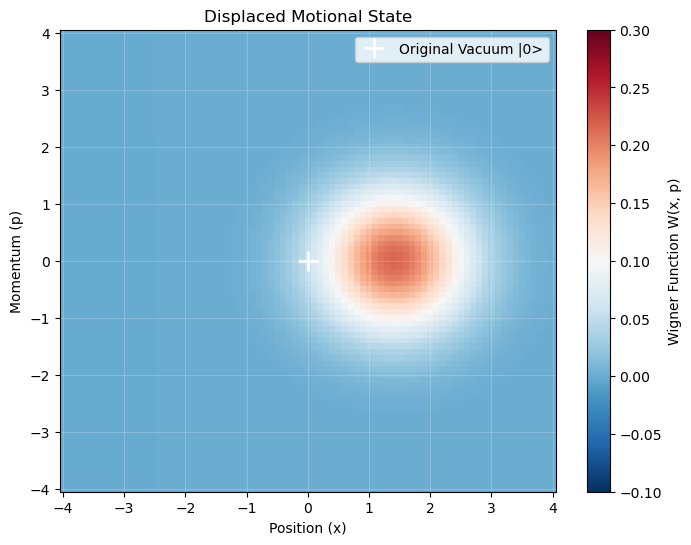

In [54]:
betastate = SDF_apply_with_alpha(1e3, 0, 1, false, nothing, 0)
plot_wigner(betastate)

Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...


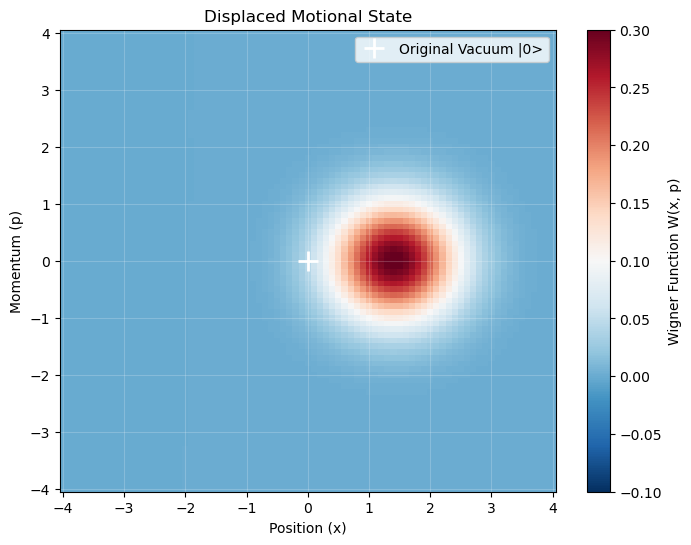

In [55]:
betastate = SDF_apply_with_alpha(1e5, 0, 1, false, nothing, 0)
plot_wigner(betastate)

In [56]:
print(betastate)

Operator(dim=42x42)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=20)]
      0.36846-0.0im            -0.0056705+3.04022e-5im    -0.00010244-0.359751im      -0.00020795+0.00613336im      -0.248058+0.00014111im     0.00464172+0.000303753im   0.000114454+0.139481im       5.43963e-5-0.00284007im      0.0678369-7.69834e-5im    -0.00149453-0.000176345im   -3.94996e-5-0.0294723im     -3.67177e-6+0.000697459im    -0.0116743+1.98322e-5im    0.000295874+4.72569e-5im     7.87993e-6+0.00427585im    -9.56572e-7-0.000115272im    0.00146312-3.30912e-6im    -4.19195e-5-8.15774e-6im     -1.0973e-6-0.00047142im     3.11512e-7+1.42573e-5im   -0.000143921+4.0651e-7im      4.59845e-6+1.03459e-6im     1.16877e-7+4.18389e-5im    -4.99116e-8-1.40238e-6im      1.1631e-5-3.94115e-8im    -4.09947e-7-1.03442e-7im    -1.00498e-8-3.10243e-6im     5.66783e-9+1.14122e-7im     -7.9649e-7+3.14989e-9im     3.06929e-8+8.52062e-9im    7.22837e-10+1.97283e-7im   -5.06988e-10-7.89944e-9im     4.72591e-8-2.13828e-10i

Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...


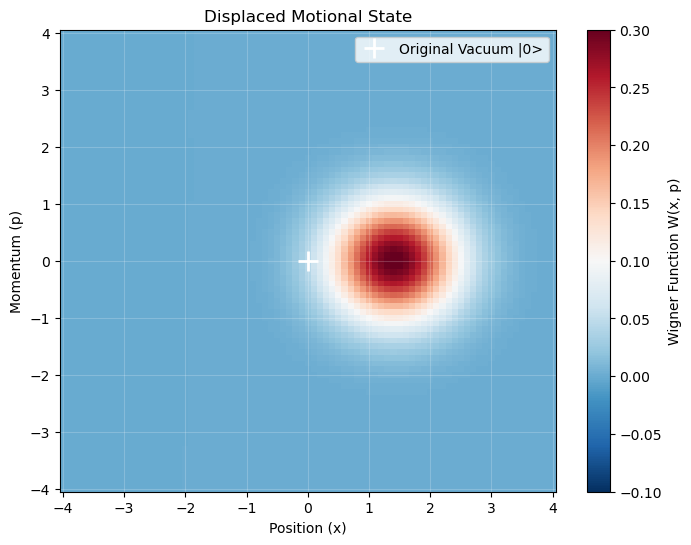

In [57]:
betastate = SDF_apply_with_alpha(1e5,0, 1, false, nothing, 0, 10000.0)
plot_wigner(betastate)

Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...


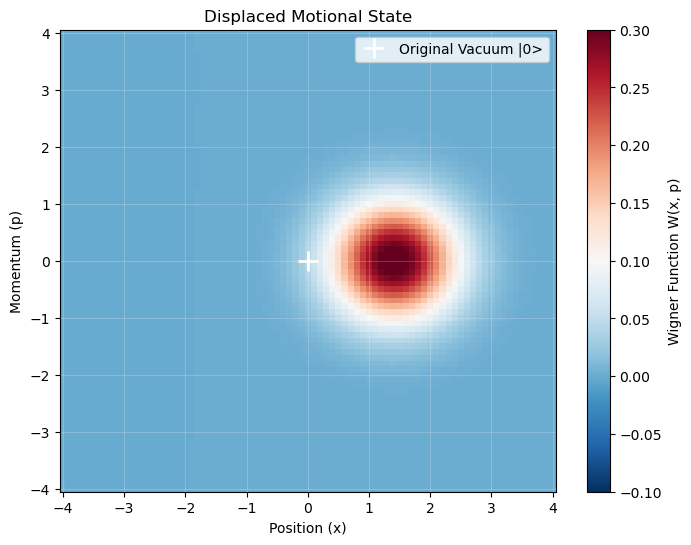

In [58]:
betastate = SDF_apply_with_alpha(1e5,0, 1, false, nothing, 0, 0.0)
plot_wigner(betastate)

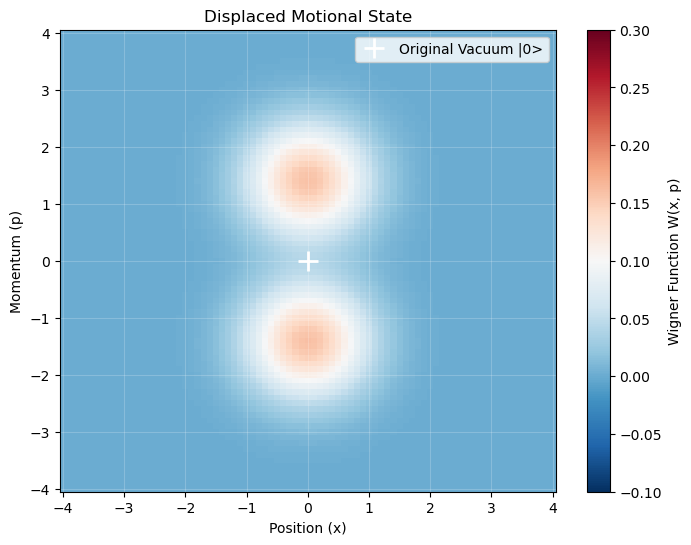

Simulating direct SDF for cat state creation...


In [64]:
betastate = SDF_apply_with_alpha(1e3,pi/2, 1, true, nothing, 0, 0.0)
plot_wigner(betastate)

In [60]:
print(betastate)

Ket(dim=42)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=20)]
   0.6071363167515837 + 5.663028796746e-5im
      3.3791559139e-7 + 0.00133037178515751im
 -0.00453015211754781 - 1.160880099e-8im
     1.83561144952e-5 - 0.6068884687881024im
   0.4284510183599076 - 1.403869952573e-5im
     -5.0521481457e-7 + 0.00094093896504893im
 -0.00183772041477072 - 1.1069407258e-7im
   -2.361973500801e-5 - 0.2466539493410813im
  0.12282581924722775 - 1.949588641838e-5im
     -3.3241280075e-7 + 0.00027103865939447im
 -0.00040636182985286 - 4.535295566e-8im
   -1.211216485556e-5 - 0.05463565493215525im
  0.02215927444618952 - 6.30682698292e-6im
      -9.325699026e-8 + 4.915154245676e-5im
   -6.170292643858e-5 - 9.91808992e-9im
    -2.88808741182e-6 - 0.00831000105956263im
  0.00291161282015305 - 1.19499851577e-6im
      -1.660254006e-8 + 6.49236135596e-6im
    -7.12052612551e-6 - 1.49601171e-9im
     -4.5466132998e-7 - 0.00096057021946499im
  0.00030028130500281 - 1.6100022884e-7im
       -2.159

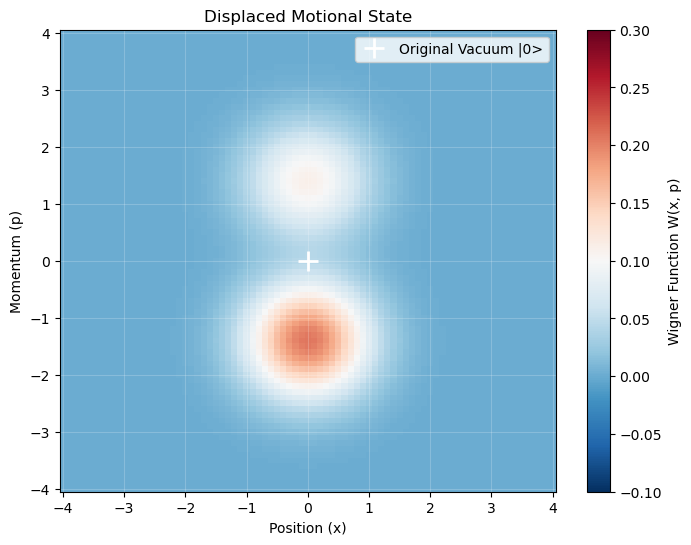

Simulating direct SDF for cat state creation...


In [63]:
betastate = SDF_apply_with_alpha(1e7,pi/2, 1, true, nothing, 0, 0.0)
plot_wigner(betastate)

Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...


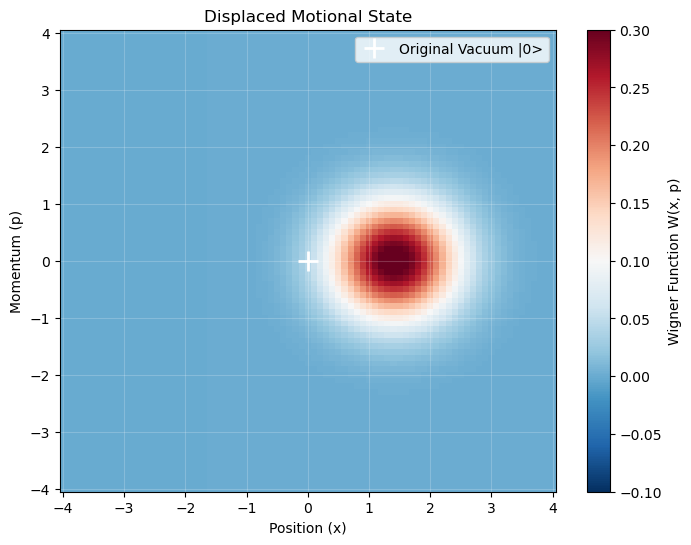

In [68]:
betastate = SDF_apply_with_alpha(1e3,0, 1, false, nothing, 0, 100.0)
plot_wigner(betastate)

Simulating direct SDF for cat state creation...


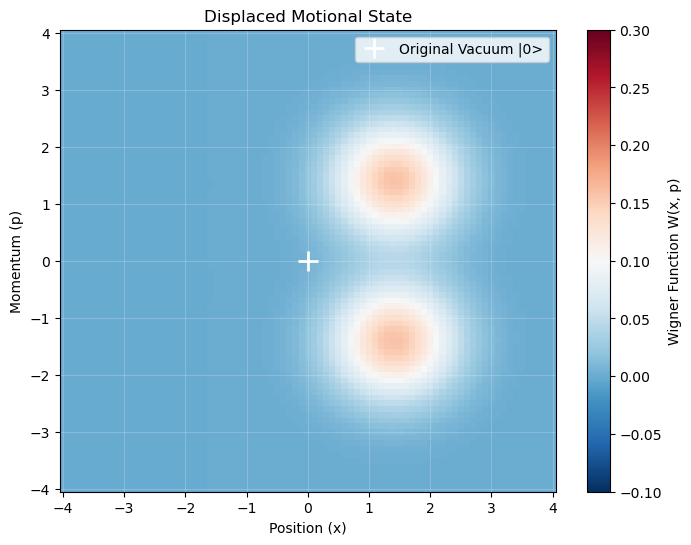

In [ ]:
finalstate = SDF_apply_with_alpha(1e3,pi/2, 1, true, betastate, 0, 0.0)
plot_wigner(finalstate)

Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...
Simulating direct SDF for cat state creation...


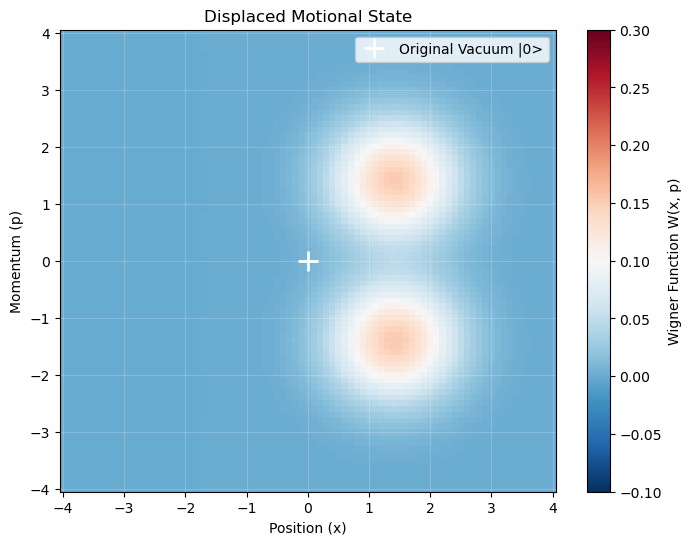

In [72]:
betastate = SDF_apply_with_alpha(1e3,0, 1, false, nothing, 0, 1000.0)
finalstate = SDF_apply_with_alpha(1e3,pi/2, 1, true, betastate, 0, 0.0)
plot_wigner(finalstate)

In [70]:
function SDF_apply_hybrid(laser_intensity = 1e4, angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0, n_th_set = 10000.0)

    # ---------------------------------------------------------
    # 1. Common Trap Initialization
    # ---------------------------------------------------------
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    B_field = 1e-13
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    
    mode = zmodes(trap_pre)[1] 
    mode.N = 20
    mode.shape = [21]

    g = ion["g"]
    e = ion["e"]
    
    # STRICTLY INITIALIZE IN GROUND STATE
    ψ_ion = normalize(g)
    ψ_mode = fockstate(mode, fock_state_n)
    
    # If a state is passed in (e.g., from Beta to Alpha), use it exactly as-is.
    ψ_initial = initial_state !== nothing ? initial_state : (ψ_ion ⊗ ψ_mode)

    if cat_state
        # ---------------------------------------------------------
        # PERFECT OPERATOR MATH (For Alpha Readout)
        # ---------------------------------------------------------
        println("Applying ideal SDF Unitary Operator (Creating perfect Cat State)...")
        alpha_complex = target_alpha * exp(1im * angle)
        
        # 1. Create the X-basis spin eigenstates (|+> and |->)
        x_plus = normalize(g + e)
        x_minus = normalize(g - e)
        
        # 2. Create the spin projection operators: P+ = |+><+| and P- = |-><-|
        P_plus = x_plus ⊗ dagger(x_plus)
        P_minus = x_minus ⊗ dagger(x_minus)
        
        # 3. Create the positive and negative motional displacements
        D_plus = IonSim.displace(mode, alpha_complex)
        D_minus = IonSim.displace(mode, -alpha_complex)
        
        # 4. Construct the ideal Entangling Unitary
        U_SDF = (P_plus ⊗ D_plus) + (P_minus ⊗ D_minus)
        
        # 5. Apply the correct math depending on whether the input is a Vector or Matrix
        if isa(ψ_initial, Ket)
            # Pure state evolution: U * |ψ>
            return U_SDF * ψ_initial
        else
            # Mixed state evolution (from master eq): U * ρ * U^†
            return U_SDF * ψ_initial * dagger(U_SDF)
        end
        
    else
        # ---------------------------------------------------------
        # MASTER EQUATION SOLVER (For Beta Signal with Noise)
        # ---------------------------------------------------------
        hbar = 1.0545718e-34       
        amu = 1.66053906e-27       
        m_Ca40 = 39.96259 * amu    
        
        omega_trap = 2 * π * trap_freq
        z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
        k_total = 2 * π / transition_λ
        k_z = k_total / sqrt(2)
        eta = k_z * z_zpf
        
        k_vec = (x̂ + ẑ) / √2
        ϵ_vec = ŷ

        dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
        
        Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
        Omega_eff = Omega_eff_Hz * 2 * π
        
        # SDF target time
        target_time_s = (2 * target_alpha) / (eta * Omega_eff)
        target_time_us = target_time_s * 1e6
        
        red_angle = (π - 2*angle ) / 2
        blue_angle = red_angle + 2 * angle

        L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_sdf = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
        
        tspan_sdf = collect(0:0.5:target_time_us)
        if tspan_sdf[end] < target_time_us
            push!(tspan_sdf, target_time_us)
        end

        I_spin = identityoperator(g.basis)  
        n_th = n_th_set           
        gamma_0 = 1e-2           
        
        # Scale per-second rates to per-microsecond rates for the solver
        gamma_plus_us = (gamma_0 * n_th) * 1e-6 
        gamma_minus_us = (gamma_0 * (n_th + 1)) * 1e-6 

        # Lindblad Jump Operators
        temp_fock_basis = FockBasis(mode.N) 
        a_op = DenseOperator(mode, mode, QuantumOptics.destroy(temp_fock_basis).data)
        at_op = DenseOperator(mode, mode, QuantumOptics.create(temp_fock_basis).data)

        a_sys = I_spin ⊗ a_op
        at_sys = I_spin ⊗ at_op

        J_cool = sqrt(gamma_minus_us) * a_sys
        J_heat = sqrt(gamma_plus_us) * at_sys
        J_ops = [J_cool, J_heat]
        J_ops_dag = dagger.(J_ops)

        # BETA SIGNAL: R(π/2) -> SDF -> R(-π/2) sequence (The SDFz)
        println("Simulating Carrier + SDF + Carrier sequence for Beta displacement with Noise...")
        
        # Calculate Carrier Pulse Time
        Omega_carrier = Omega_eff * exp(-eta^2 / 2)
        t_pi_half_s = (π / 2) / Omega_carrier
        t_pi_half_us = t_pi_half_s * 1e6
        tspan_carrier = [0.0, t_pi_half_us]
        
        # 1. First Carrier Pulse R(π/2)
        println("  -> Applying R(π/2) Carrier Pulse...")
        L_pi2 = Laser(Δ = 0, ϕ = π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_pi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_pi2])
        H_pi2 = hamiltonian(trap_pi2, timescale=1e-6, rwa_cutoff=Inf)
        f_dyn_pi2(time_t, rho_state) = (H_pi2(time_t, rho_state), J_ops, J_ops_dag)
        _, sol_pi2 = timeevolution.master_dynamic(tspan_carrier, ψ_initial, f_dyn_pi2)
        ψ_after_pi2 = sol_pi2[end]

        # 2. SDF Pulse (Acts as uniform displacement since state is now an eigenstate)
        println("  -> Applying SDF Displacement...")
        H_sdf = hamiltonian(trap_sdf, timescale=1e-6, rwa_cutoff=Inf)
        f_dyn_sdf(time_t, rho_state) = (H_sdf(time_t, rho_state), J_ops, J_ops_dag)
        _, sol_sdf = timeevolution.master_dynamic(tspan_sdf, ψ_after_pi2, f_dyn_sdf)
        ψ_after_sdf = sol_sdf[end]

        # 3. Second Carrier Pulse R(-π/2)
        println("  -> Applying R(-π/2) Carrier Pulse...")
        L_mpi2 = Laser(Δ = 0, ϕ = -π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_mpi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_mpi2])
        H_mpi2 = hamiltonian(trap_mpi2, timescale=1e-6, rwa_cutoff=Inf)
        f_dyn_mpi2(time_t, rho_state) = (H_mpi2(time_t, rho_state), J_ops, J_ops_dag)
        _, sol_mpi2 = timeevolution.master_dynamic(tspan_carrier, ψ_after_sdf, f_dyn_mpi2)

        return sol_mpi2[end]
    end
end

SDF_apply_hybrid (generic function with 8 methods)

Simulating Carrier + SDF + Carrier sequence for Beta displacement with Noise...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...
Applying ideal SDF Unitary Operator (Creating perfect Cat State)...


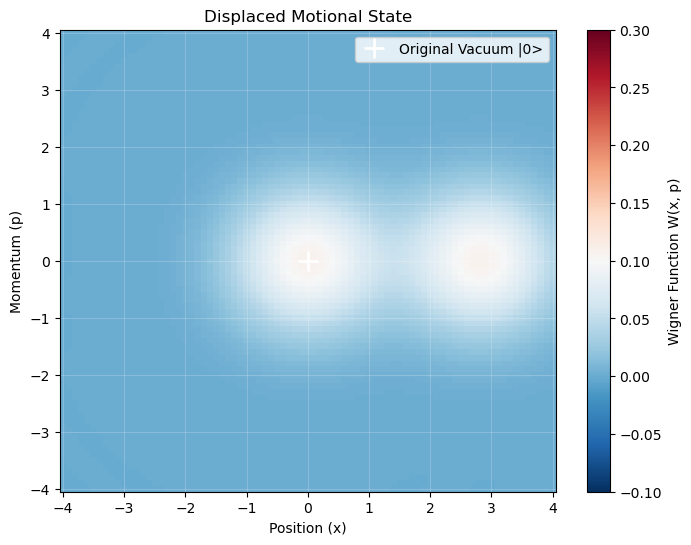

In [71]:
betastate = SDF_apply_hybrid(1e3,0, 1, false, nothing, 0, 10000.0)
finalstate = SDF_apply_hybrid(1e3,pi/2, 1, true, betastate, 0, 0.0)
plot_wigner(finalstate)

In [73]:
using LinearAlgebra
using QuantumOptics
using IonSim

In [ ]:
using LinearAlgebra
using QuantumOptics
using IonSim

# Helper function to calculate Generalized Laguerre Polynomials L_n(x)
function laguerre(n::Int, x::Float64)
    if n == 0 return 1.0 end
    if n == 1 return 1.0 - x end
    L_prev2 = 1.0
    L_prev1 = 1.0 - x
    L_curr = 0.0
    for k in 1:(n-1)
        L_curr = ((2k + 1 - x) * L_prev1 - k * L_prev2) / (k + 1)
        L_prev2 = L_prev1
        L_prev1 = L_curr
    end
    return L_curr
end

function get_qcrb_coordinates(n_fock::Int=0, r_squeeze::Float64=0.0, laser_intensity::Float64=1e3, gamma_0::Float64=1e-2, n_th_set::Float64=1000.0)
    
    # ---------------------------------------------------------
    # 1. FIXED PARAMETERS & EXACT TIME CALCULATION
    # ---------------------------------------------------------
    beta_signal = 1.0
    d_beta = 1e-4 # Perturb the SIGNAL, not the readout!
    
    trap_freq = 19e5 
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))
    B_field = 1e-13
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    
    sim_mode = zmodes(trap_pre)[1]
    sim_mode.N = 20
    sim_mode.shape = [21]
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    # EXACT TIME CALCULATION FOR BETA = 1.0
    t_sig_s = (2 * beta_signal) / (eta * Omega_eff)
    t_sig_us = t_sig_s * 1e6
    
    println("==================================================")
    println(" EXACT TIME CALCULATION")
    println("==================================================")
    println(" Signal Magnitude (β): ", beta_signal)
    println(" Exposure Time (t)   : ", round(t_sig_us, digits=2), " μs")
    println(" Base Gamma Rate     : ", gamma_0)
    println(" Thermal Phonons (n) : ", n_th_set)
    println("==================================================")

    # ---------------------------------------------------------
    # 2. GENERATE THE NOISY SIGNAL STATES (Base & Perturbed)
    # ---------------------------------------------------------
    b_fock = FockBasis(20)
    vac_qo = fockstate(b_fock, n_fock)
    
    if r_squeeze > 0.0
        squeeze_op = squeeze(b_fock, r_squeeze * exp(1im * 0.0))
        initial_m_qo = squeeze_op * vac_qo
    else
        initial_m_qo = vac_qo
    end
    
    initial_m_sim = Ket(sim_mode, initial_m_qo.data)
    initial_sys = normalize(ion["g"]) ⊗ initial_m_sim

    println("\nRunning master equation for Base β Signal...")
    noisy_beta_state = SDF_apply_hybrid(laser_intensity, 0.0, beta_signal, false, initial_sys, n_fock, n_th_set)
    
    println("\nRunning master equation for Perturbed β Signal (+ d_beta)...")
    noisy_beta_state_pert = SDF_apply_hybrid(laser_intensity, 0.0, beta_signal + d_beta, false, initial_sys, n_fock, n_th_set)

    # ---------------------------------------------------------
    # 3. SWEEP ALPHA & GENERATE COORDINATES
    # ---------------------------------------------------------
    alphas = collect(0.1:0.1:1.6)
    sim_qcrbs = Float64[]
    theory_thermal_qcrbs = Float64[]
    theory_closed_qcrbs = Float64[]

    # Analytical Energy Decay Rate Γ
    Gamma_t = (gamma_0 * 1e-6) * t_sig_us

    println("\nSweeping α readout (generating coordinates)...")
    for a in alphas
        # --- A. SIMULATION (Applying same alpha to both beta states) ---
        state_a = SDF_apply_with_alpha(laser_intensity, π/2, a, true, noisy_beta_state, n_fock, n_th_set)
        state_a_pert = SDF_apply_with_alpha(laser_intensity, π/2, a, true, noisy_beta_state_pert, n_fock, n_th_set)

        _, qcrb_sim = calculate_qcrb(state_a, state_a_pert, d_beta)
        push!(sim_qcrbs, qcrb_sim)

        # --- B. FULL THERMAL-SYSTEM THEORY ---
        # Upgraded to match the (2*n_th + 1) thermal environment envelope
        thermal_heating_factor = (2 * n_th_set) + 1.0
        exp_term_open = 4 * a^2 * (thermal_heating_factor * (1 - exp(-Gamma_t)) + exp(-Gamma_t - 2*r_squeeze))
        numerator_open = exp(exp_term_open)
        
        L_val_open = laguerre(n_fock, 4 * a^2 * exp(-Gamma_t - 2*r_squeeze))
        denominator_open = 16 * a^2 * exp(-Gamma_t) * (L_val_open^2)
        
        push!(theory_thermal_qcrbs, numerator_open / denominator_open)

        # --- C. CLOSED-SYSTEM THEORY (Noiseless Baseline) ---
        exp_term_closed = 4 * a^2 * exp(-2*r_squeeze)
        numerator_closed = exp(exp_term_closed)
        
        L_val_closed = laguerre(n_fock, 4 * a^2 * exp(-2*r_squeeze))
        denominator_closed = 16 * a^2 * (L_val_closed^2)
        
        push!(theory_closed_qcrbs, numerator_closed / denominator_closed)
    end

    return alphas, sim_qcrbs, theory_thermal_qcrbs, theory_closed_qcrbs
end

get_qcrb_coordinates (generic function with 6 methods)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 0.01
 Thermal Phonons (n) : 1000.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement with Noise...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement with Noise...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat s

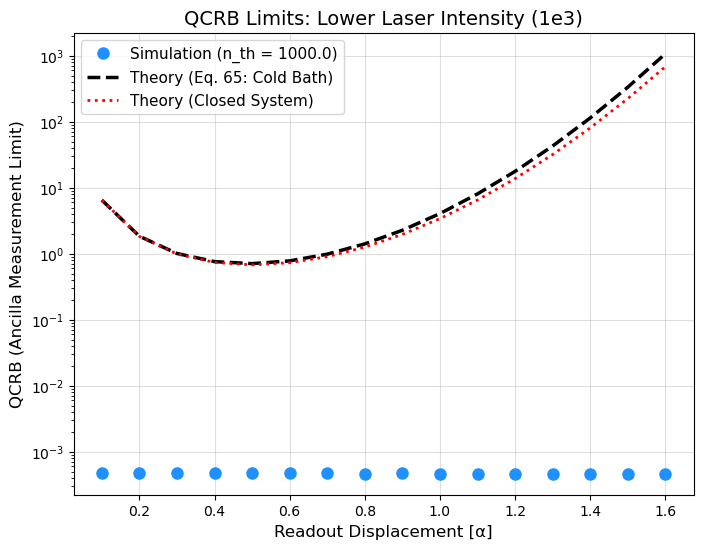

In [81]:
using PyPlot

# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.0, 1e3, 1e-2, 1000.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 0.01
 Thermal Phonons (n) : 1000.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement with Noise...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement with Noise...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...


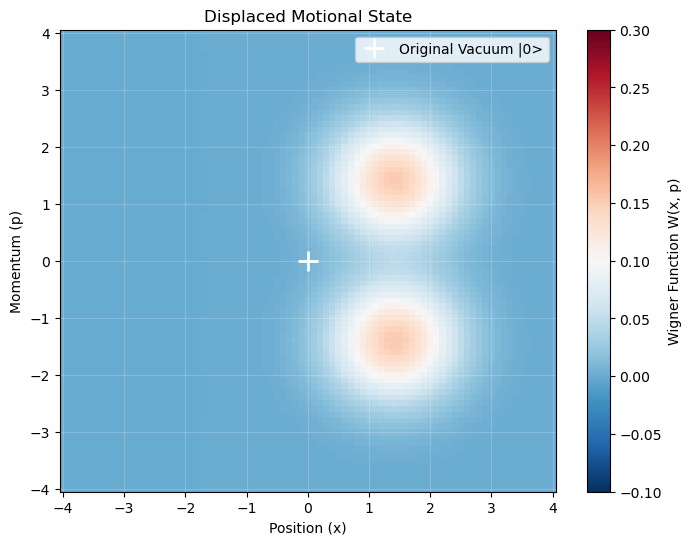

In [83]:
n_fock::Int=0
 r_squeeze::Float64=0.0
  laser_intensity::Float64=1e3
   gamma_0::Float64=1e-2
    n_th_set::Float64=1000.0
    
    # ---------------------------------------------------------
    # 1. FIXED PARAMETERS & EXACT TIME CALCULATION
    # ---------------------------------------------------------
    beta_signal = 1.0
    d_beta = 1e-4 # Perturb the SIGNAL, not the readout!
    
    trap_freq = 19e5 
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))
    B_field = 1e-13
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    
    sim_mode = zmodes(trap_pre)[1]
    sim_mode.N = 20
    sim_mode.shape = [21]
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    # EXACT TIME CALCULATION FOR BETA = 1.0
    t_sig_s = (2 * beta_signal) / (eta * Omega_eff)
    t_sig_us = t_sig_s * 1e6
    
    println("==================================================")
    println(" EXACT TIME CALCULATION")
    println("==================================================")
    println(" Signal Magnitude (β): ", beta_signal)
    println(" Exposure Time (t)   : ", round(t_sig_us, digits=2), " μs")
    println(" Base Gamma Rate     : ", gamma_0)
    println(" Thermal Phonons (n) : ", n_th_set)
    println("==================================================")

    # ---------------------------------------------------------
    # 2. GENERATE THE NOISY SIGNAL STATES (Base & Perturbed)
    # ---------------------------------------------------------
    b_fock = FockBasis(20)
    vac_qo = fockstate(b_fock, n_fock)
    
    if r_squeeze > 0.0
        squeeze_op = squeeze(b_fock, r_squeeze * exp(1im * 0.0))
        initial_m_qo = squeeze_op * vac_qo
    else
        initial_m_qo = vac_qo
    end
    
    initial_m_sim = Ket(sim_mode, initial_m_qo.data)
    initial_sys = normalize(ion["g"]) ⊗ initial_m_sim

    println("\nRunning master equation for Base β Signal...")
    noisy_beta_state = SDF_apply_hybrid(laser_intensity, 0.0, beta_signal, false, initial_sys, n_fock, n_th_set)
    
    println("\nRunning master equation for Perturbed β Signal (+ d_beta)...")
    noisy_beta_state_pert = SDF_apply_hybrid(laser_intensity, 0.0, beta_signal + d_beta, false, initial_sys, n_fock, n_th_set)

    # ---------------------------------------------------------
    # 3. SWEEP ALPHA & GENERATE COORDINATES
    # ---------------------------------------------------------
    alphas = collect(0.1:0.1:1.6)
    sim_qcrbs = Float64[]
    theory_thermal_qcrbs = Float64[]
    theory_closed_qcrbs = Float64[]

    # Analytical Energy Decay Rate Γ
    Gamma_t = (gamma_0 * 1e-6) * t_sig_us

    println("\nSweeping α readout (generating coordinates)...")
    a = 1.0
        # --- A. SIMULATION (Applying same alpha to both beta states) ---
        state_a = SDF_apply_with_alpha(laser_intensity, π/2, a, true, noisy_beta_state, n_fock, n_th_set)
        state_a_pert = SDF_apply_with_alpha(laser_intensity, π/2, a, true, noisy_beta_state_pert, n_fock, n_th_set)

        _, qcrb_sim = calculate_qcrb(state_a, state_a_pert, d_beta)
        push!(sim_qcrbs, qcrb_sim)

        # --- B. FULL THERMAL-SYSTEM THEORY ---
        # Upgraded to match the (2*n_th + 1) thermal environment envelope
        thermal_heating_factor = (2 * n_th_set) + 1.0
        exp_term_open = 4 * a^2 * (thermal_heating_factor * (1 - exp(-Gamma_t)) + exp(-Gamma_t - 2*r_squeeze))
        numerator_open = exp(exp_term_open)
        
        L_val_open = laguerre(n_fock, 4 * a^2 * exp(-Gamma_t - 2*r_squeeze))
        denominator_open = 16 * a^2 * exp(-Gamma_t) * (L_val_open^2)
        
        push!(theory_thermal_qcrbs, numerator_open / denominator_open)

        # --- C. CLOSED-SYSTEM THEORY (Noiseless Baseline) ---
        exp_term_closed = 4 * a^2 * exp(-2*r_squeeze)
        numerator_closed = exp(exp_term_closed)
        
        L_val_closed = laguerre(n_fock, 4 * a^2 * exp(-2*r_squeeze))
        denominator_closed = 16 * a^2 * (L_val_closed^2)
        
        push!(theory_closed_qcrbs, numerator_closed / denominator_closed)

        plot_wigner(state_a)

In [84]:

println("Simulated QCRB: ", sim_qcrbs)
println("Theoretical Thermal QCRB: ", theory_thermal_qcrbs)
println("Theoretical Closed QCRB: ", theory_closed_qcrbs)

Simulated QCRB: [0.00046607919922409175]
Theoretical Thermal QCRB: [4.071312201908322]
Theoretical Closed QCRB: [3.4123843770715148]


 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 0.01
 Thermal Phonons (n) : 1000.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement with Noise...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement with Noise...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat s

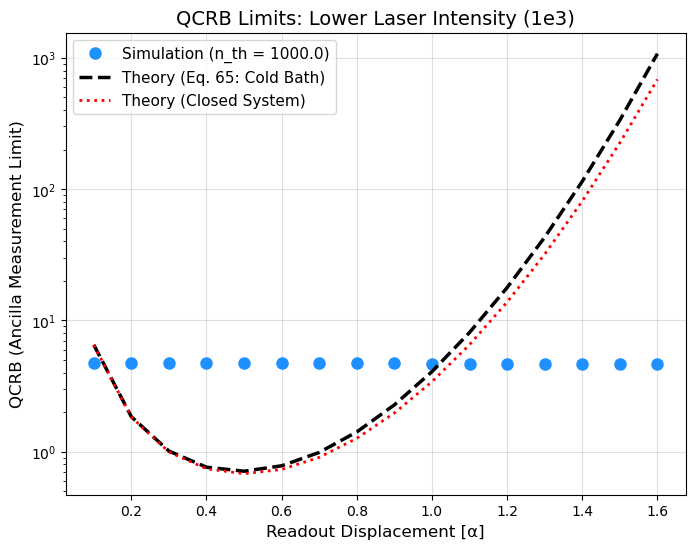

In [86]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.0, 1e3, 1e-2, 1000.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim* 1e4, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

In [100]:
using LinearAlgebra
using QuantumOptics
using IonSim

# Helper function to calculate Generalized Laguerre Polynomials L_n(x)
function laguerre(n::Int, x::Float64)
    if n == 0 return 1.0 end
    if n == 1 return 1.0 - x end
    L_prev2 = 1.0
    L_prev1 = 1.0 - x
    L_curr = 0.0
    for k in 1:(n-1)
        L_curr = ((2k + 1 - x) * L_prev1 - k * L_prev2) / (k + 1)
        L_prev2 = L_prev1
        L_prev1 = L_curr
    end
    return L_curr
end

function get_qcrb_coordinates(n_fock::Int=0, r_squeeze::Float64=0.0, laser_intensity::Float64=1e3, gamma_0::Float64=1e-2, n_th_set::Float64=1000.0)
    
    # ---------------------------------------------------------
    # 1. FIXED PARAMETERS & EXACT TIME CALCULATION
    # ---------------------------------------------------------
    beta_signal = 1.0
    d_beta = 1e-4 # Perturb the SIGNAL, not the readout!
    
    trap_freq = 19e5 
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))
    B_field = 1e-13
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    
    sim_mode = zmodes(trap_pre)[1]
    sim_mode.N = cutoff_N
    sim_mode.shape = [cutoff_N + 1]

    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    # EXACT TIME CALCULATION FOR BETA = 1.0
    t_sig_s = (2 * beta_signal) / (eta * Omega_eff)
    t_sig_us = t_sig_s * 1e6
    
    println("==================================================")
    println(" EXACT TIME CALCULATION")
    println("==================================================")
    println(" Signal Magnitude (β): ", beta_signal)
    println(" Exposure Time (t)   : ", round(t_sig_us, digits=2), " μs")
    println(" Base Gamma Rate     : ", gamma_0)
    println(" Thermal Phonons (n) : ", n_th_set)
    println("==================================================")

    # ---------------------------------------------------------
    # 2. GENERATE THE NOISY SIGNAL STATES (Base & Perturbed)
    # ---------------------------------------------------------
    b_fock = FockBasis(20)
    vac_qo = fockstate(b_fock, n_fock)
    
    if r_squeeze > 0.0
        squeeze_op = squeeze(b_fock, r_squeeze * exp(1im * 0.0))
        initial_m_qo = squeeze_op * vac_qo
    else
        initial_m_qo = vac_qo
    end
    
    initial_m_sim = Ket(sim_mode, initial_m_qo.data)
    initial_sys = normalize(ion["g"]) ⊗ initial_m_sim

    println("\nRunning master equation for Base β Signal...")
    noisy_beta_state = SDF_apply_with_alpha(laser_intensity, 0.0, beta_signal, false, initial_sys, n_fock, n_th_set)
    
    println("\nRunning master equation for Perturbed β Signal (+ d_beta)...")
    noisy_beta_state_pert = SDF_apply_with_alpha(laser_intensity, 0.0, beta_signal + d_beta, false, initial_sys, n_fock, n_th_set)

    # ---------------------------------------------------------
    # 3. SWEEP ALPHA & GENERATE COORDINATES
    # ---------------------------------------------------------
    alphas = collect(0.1:0.1:1.6)
    sim_qcrbs = Float64[]
    theory_thermal_qcrbs = Float64[]
    theory_closed_qcrbs = Float64[]

    # Analytical Energy Decay Rate Γ
    Gamma_t = (gamma_0 * 1e-6) * t_sig_us

    println("\nSweeping α readout (generating coordinates)...")
    for a in alphas
        # --- A. SIMULATION ---
        # 1. Use angle = 0.0 for Alpha so it is purely REAL (orthogonal to imaginary Beta)
        state_a_full = SDF_apply_with_alpha(laser_intensity, pi/2, a, true, noisy_beta_state, n_fock, n_th_set)
        state_a_pert_full = SDF_apply_with_alpha(laser_intensity, pi/2, a, true, noisy_beta_state_pert, n_fock, n_th_set)

        # 2. CRITICAL: Trace out the motional mode (subsystem 2) to get the Ancilla limit!
        rho_spin_a = ptrace(state_a_full, 2)
        rho_spin_a_pert = ptrace(state_a_pert_full, 2)
        
        # 3. Calculate QCRB purely on the 2x2 Spin density matrix
        _, qcrb_sim = calculate_qcrb(rho_spin_a, rho_spin_a_pert, d_beta)
        push!(sim_qcrbs, qcrb_sim)

        # --- B. FULL THERMAL-SYSTEM THEORY ---
        # Upgraded to match the (2*n_th + 1) thermal environment envelope
        thermal_heating_factor = (2 * n_th_set) + 1.0
        exp_term_open = 4 * a^2 * (thermal_heating_factor * (1 - exp(-Gamma_t)) + exp(-Gamma_t - 2*r_squeeze))
        numerator_open = exp(exp_term_open)
        
        L_val_open = laguerre(n_fock, 4 * a^2 * exp(-Gamma_t - 2*r_squeeze))
        denominator_open = 16 * a^2 * exp(-Gamma_t) * (L_val_open^2)
        
        push!(theory_thermal_qcrbs, numerator_open / denominator_open)

        # --- C. CLOSED-SYSTEM THEORY (Noiseless Baseline) ---
        exp_term_closed = 4 * a^2 * exp(-2*r_squeeze)
        numerator_closed = exp(exp_term_closed)
        
        L_val_closed = laguerre(n_fock, 4 * a^2 * exp(-2*r_squeeze))
        denominator_closed = 16 * a^2 * (L_val_closed^2)
        
        push!(theory_closed_qcrbs, numerator_closed / denominator_closed)
    end

    return alphas, sim_qcrbs, theory_thermal_qcrbs, theory_closed_qcrbs
end

get_qcrb_coordinates (generic function with 6 methods)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 0.01
 Thermal Phonons (n) : 1000.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simul

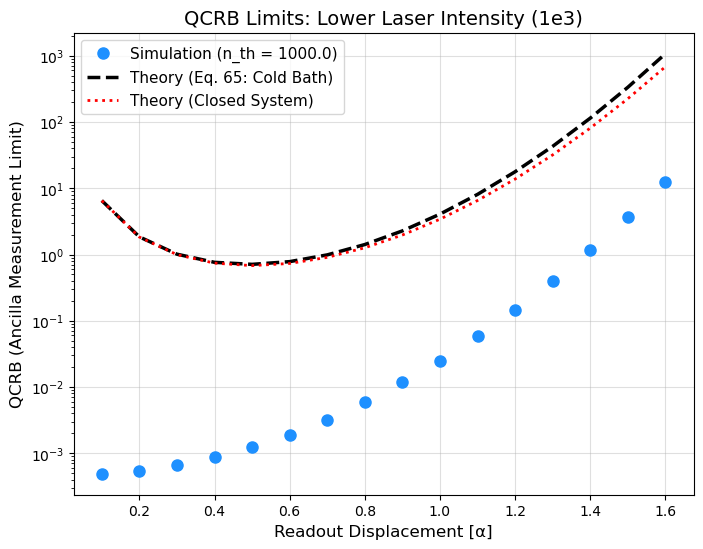

In [88]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.0, 1e3, 1e-2, 1000.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

In [90]:

println("Simulated QCRB: ", y_sim)
println("Theoretical Thermal QCRB: ", y_theory_open)
println("Theoretical Closed QCRB: ", y_theory_closed)

Simulated QCRB: [0.0004906192282053151, 0.0005468781669259271, 0.0006571853752099406, 0.0008630895663497196, 0.0012328270608622897, 0.0019108540002497176, 0.0032269312980313, 0.0058774254273977035, 0.011706083579149488, 0.02487681191308005, 0.058214906237976684, 0.14717688540222237, 0.40162602374452694, 1.1782829264860029, 3.7162820104277667, 12.400217746712094]
Theoretical Thermal QCRB: [6.516704807805893, 1.846644945811621, 1.0113305439962998, 0.762052315655992, 0.7102492661007619, 0.7808565007282061, 0.9873644256910752, 1.414393665589816, 2.2731017420255557, 4.071312201908322, 8.088285000853379, 17.76084521232219, 42.99328388173774, 114.49047290315765, 334.8558543672851, 1074.2177862321034]
Theoretical Closed QCRB: [6.505067338702425, 1.8336107359247031, 0.9953676490002362, 0.7408128434784966, 0.6795704571147613, 0.7327596904507904, 0.9055264113720194, 1.263263409721004, 1.9701945792709512, 3.4123843770715148, 6.532507837299321, 13.773798998170593, 31.902448069128614, 81.00142965009

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 0.01
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulati

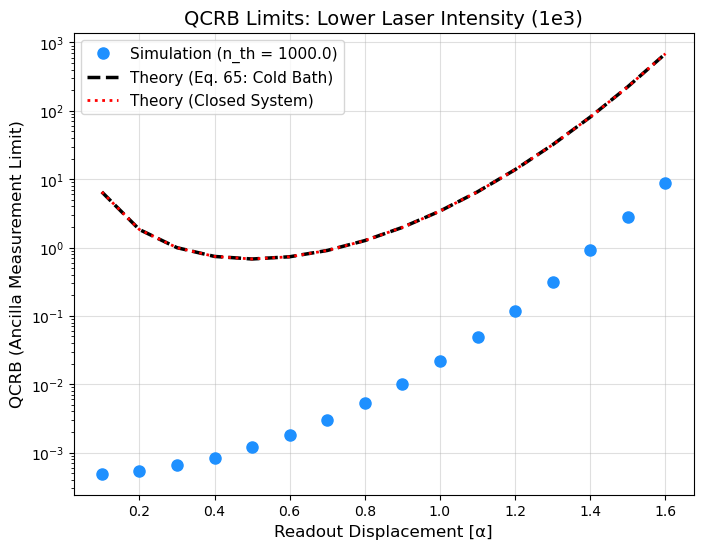

In [91]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.0, 1e3, 1e-2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

In [92]:
function SDF_apply_with_alpha(laser_intensity = 1e4, angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0, n_th_set = 10000.0)

    # ---------------------------------------------------------
    # 1. Common Trap Initialization
    # ---------------------------------------------------------
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] 
    mode_z.N = 20
    mode_z.shape = [21]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    B_field = 1e-13
    
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    mode = zmodes(trap_pre)[1]

    # STRICTLY INITIALIZE IN GROUND STATE
    ψ_ion = normalize(ion["g"])
    ψ_mode = fockstate(mode, fock_state_n)
    
    # If a state is passed in (e.g., from Beta to Alpha), use it exactly as-is.
    ψ_initial = initial_state !== nothing ? initial_state : (ψ_ion ⊗ ψ_mode)

    # ---------------------------------------------------------
    # 2. Physics & Dynamic Time Calculation
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    # SDF target time
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    
    red_angle = (π - 2*angle ) / 2
    blue_angle = red_angle + 2 * angle

    if (cat_state)
        red_angle = -angle
        blue_angle = angle
    end

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    trap_sdf = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
    h_sdf = hamiltonian(trap_sdf, timescale=1e-6, rwa_cutoff=Inf)
    
    tspan_sdf = collect(0:0.5:target_time_us)
    if tspan_sdf[end] < target_time_us
        push!(tspan_sdf, target_time_us)
    end

    # ---------------------------------------------------------
    # 3. LASER SEQUENCE EXECUTION
    # ---------------------------------------------------------
    if cat_state
        # ALPHA READOUT: Direct SDF on Current State
        println("Simulating direct SDF for cat state creation...")
        
        # CRITICAL FIX: Safe evolution for Density Matrices
        if isa(ψ_initial, Operator)
            # Use master_dynamic with empty jump arrays for pure U*rho*U^dag evolution
            f_dyn_alpha(time_t, rho_state) = (h_sdf(time_t, rho_state), [], [])
            tout, sol = timeevolution.master_dynamic(tspan_sdf, ψ_initial, f_dyn_alpha)
            return sol[end]
        else
            # Standard Schrödinger evolution for pure Kets
            tout, sol = timeevolution.schroedinger_dynamic(tspan_sdf, ψ_initial, h_sdf)
            return sol[end]
        end
    else
        I_spin = identityoperator(ion["g"].basis)  
        n_th = n_th_set           
        gamma_0 = 1e-2           
    
        # CRITICAL: Scale per-second rates to per-microsecond rates for the solver
        gamma_plus_us = (gamma_0 * n_th) * 1e-6 
        gamma_minus_us = (gamma_0 * (n_th + 1)) * 1e-6 
        Gamma_eff_us = (gamma_plus_us + gamma_minus_us) / 2

        trap_active = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
        H_SDF_active = hamiltonian(trap_active, timescale=1e-6, rwa_cutoff=3e5)

        # Lindblad Jump Operators
        active_mode = zmodes(trap_active)[1]
        temp_fock_basis = FockBasis(active_mode.N) 
        a_op = DenseOperator(active_mode, active_mode, QuantumOptics.destroy(temp_fock_basis).data)
        at_op = DenseOperator(active_mode, active_mode, QuantumOptics.create(temp_fock_basis).data)

        a_sys = I_spin ⊗ a_op
        at_sys = I_spin ⊗ at_op

        J_cool = sqrt(gamma_minus_us) * a_sys
        J_heat = sqrt(gamma_plus_us) * at_sys
        J_ops = [J_cool, J_heat]
        J_ops_dag = dagger.(J_ops)

        # Execute Solver Definition
        function f_dyn(time_t, rho_state)
            return (H_SDF_active(time_t, rho_state), J_ops, J_ops_dag)
        end

        # BETA SIGNAL: R(π/2) -> SDF -> R(-π/2) sequence (The SDFz)
        println("Simulating Carrier + SDF + Carrier sequence for Beta displacement...")
        
        # Calculate Carrier Pulse Time
        Omega_carrier = Omega_eff * exp(-eta^2 / 2)
        t_pi_half_s = (π / 2) / Omega_carrier
        t_pi_half_us = t_pi_half_s * 1e6
        tspan_carrier = [0.0, t_pi_half_us]
        
        # 1. First Carrier Pulse R(π/2)
        println("  -> Applying R(π/2) Carrier Pulse...")
        L_pi2 = Laser(Δ = 0, ϕ = π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_pi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_pi2])
        H_pi2_active = hamiltonian(trap_pi2, timescale=1e-6, rwa_cutoff=Inf)
        f_dyn_pi2(time_t, rho_state) = (H_pi2_active(time_t, rho_state), J_ops, J_ops_dag)
        
        # Convert initial state to density matrix if it isn't already to prevent matching errors
        rho_initial = isa(ψ_initial, Ket) ? dm(ψ_initial) : ψ_initial
        _, sol_pi2 = timeevolution.master_dynamic(tspan_carrier, rho_initial, f_dyn_pi2)
        ψ_after_pi2 = sol_pi2[end]

        # 2. SDF Pulse
        println("  -> Applying SDF Displacement...")
        _, sol_sdf = timeevolution.master_dynamic(tspan_sdf, ψ_after_pi2, f_dyn)
        ψ_after_sdf = sol_sdf[end]

        # 3. Second Carrier Pulse R(-π/2)
        println("  -> Applying R(-π/2) Carrier Pulse...")
        L_mpi2 = Laser(Δ = 0, ϕ = -π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_mpi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_mpi2])
        H_mpi2_active = hamiltonian(trap_mpi2, timescale=1e-6, rwa_cutoff=Inf)
        f_dyn_mpi2(time_t, rho_state) = (H_mpi2_active(time_t, rho_state), J_ops, J_ops_dag)
        _, sol_mpi2 = timeevolution.master_dynamic(tspan_carrier, ψ_after_sdf, f_dyn_mpi2)

        return sol_mpi2[end]
    end
end

SDF_apply_with_alpha (generic function with 8 methods)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 0.01
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulati

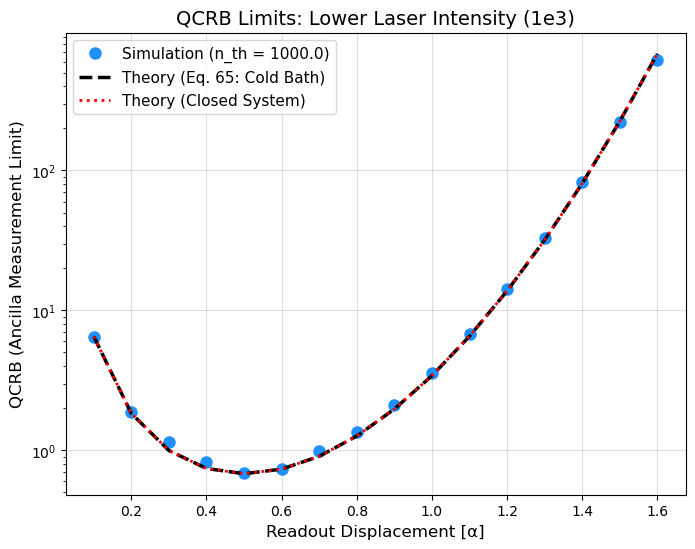

In [93]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.0, 1e3, 1e-2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 0.01
 Thermal Phonons (n) : 100.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simula

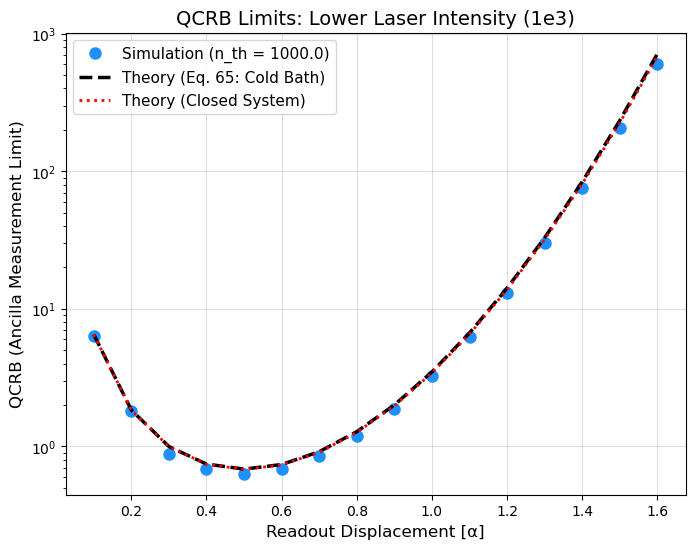

In [94]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.0, 1e3, 1e-2, 100.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 0.01
 Thermal Phonons (n) : 1000.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simul

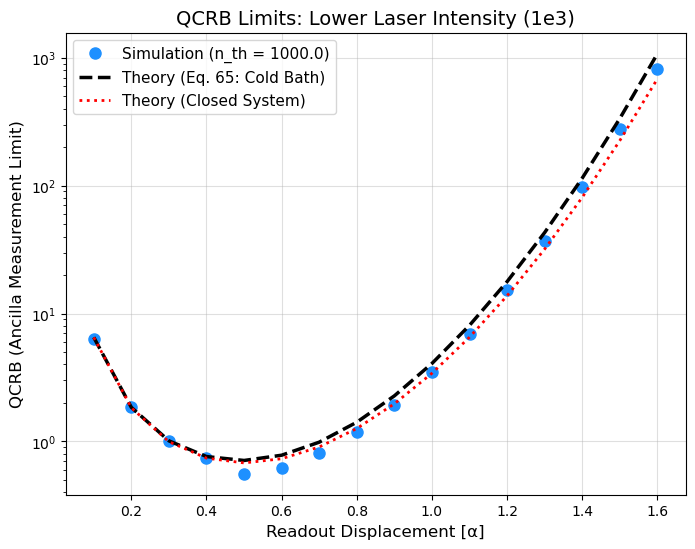

In [95]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.0, 1e3, 1e-2, 1000.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 0.01
 Thermal Phonons (n) : 1000.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simul

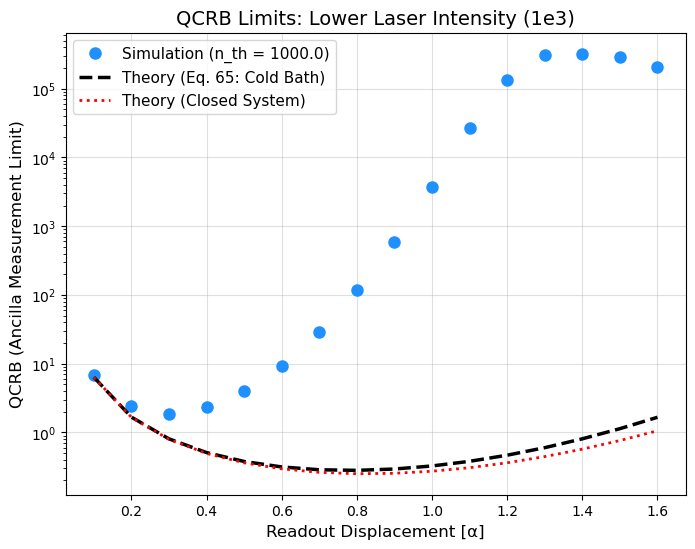

In [97]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e3, 1e-2, 1000.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

In [98]:

println("Simulated QCRB: ", y_sim)
println("Theoretical Thermal QCRB: ", y_theory_open)
println("Theoretical Closed QCRB: ", y_theory_closed)

Simulated QCRB: [6.838420132625139, 2.418596853162731, 1.8663181553001984, 2.324540808408228, 4.056171994422411, 9.272817942289853, 29.062586108816923, 116.66868500037423, 595.6189461797338, 3685.325211174257, 26649.34030349491, 133429.3021944126, 307022.47403609595, 323493.85166756954, 288719.3593777355, 207427.13654045924]
Theoretical Thermal QCRB: [6.354000319946008, 1.6690145996814783, 0.8055004276324608, 0.5085008965212118, 0.37747690095636055, 0.3142402675211217, 0.2860338730480137, 0.2804129369007367, 0.2932059218514885, 0.32482747468197115, 0.37947017538033284, 0.4658284958813864, 0.5992977236675531, 0.8063606257548849, 1.1328546232829175, 1.659599564661926]
Theoretical Closed QCRB: [6.342649868093384, 1.6572304629216674, 0.7927823851311852, 0.4943238468565428, 0.3611669652524415, 0.29487873368175405, 0.2623186928048436, 0.25044141696662076, 0.25412263804742735, 0.2722400792859572, 0.30645860599430486, 0.36122788671304734, 0.44465693405096784, 0.5704336735220437, 0.761394264487

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 0.01
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulati

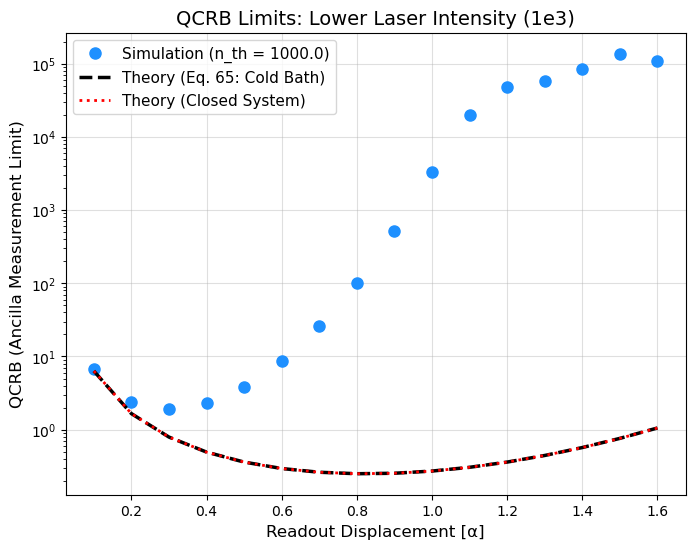

In [99]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e3, 1e-2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

In [101]:
function SDF_apply_with_alpha(laser_intensity = 1e4, angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0, n_th_set = 10000.0)

    # ---------------------------------------------------------
    # 1. Common Trap Initialization
    # ---------------------------------------------------------
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    cutoff_N = 50
    mode_z = zmodes(chain)[1] 
    mode_z.N = cutoff_N
    mode_z.shape = [cutoff_N + 1]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    B_field = 1e-13
    
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    mode = zmodes(trap_pre)[1]

    # STRICTLY INITIALIZE IN GROUND STATE
    ψ_ion = normalize(ion["g"])
    ψ_mode = fockstate(mode, fock_state_n)
    
    # If a state is passed in (e.g., from Beta to Alpha), use it exactly as-is.
    ψ_initial = initial_state !== nothing ? initial_state : (ψ_ion ⊗ ψ_mode)

    # ---------------------------------------------------------
    # 2. Physics & Dynamic Time Calculation
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    # SDF target time
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    
    red_angle = (π - 2*angle ) / 2
    blue_angle = red_angle + 2 * angle

    if (cat_state)
        red_angle = -angle
        blue_angle = angle
    end

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    trap_sdf = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
    h_sdf = hamiltonian(trap_sdf, timescale=1e-6, rwa_cutoff=Inf)
    
    tspan_sdf = collect(0:0.5:target_time_us)
    if tspan_sdf[end] < target_time_us
        push!(tspan_sdf, target_time_us)
    end

    # ---------------------------------------------------------
    # 3. LASER SEQUENCE EXECUTION
    # ---------------------------------------------------------
    if cat_state
        # ALPHA READOUT: Direct SDF on Current State
        println("Simulating direct SDF for cat state creation...")
        
        # CRITICAL FIX: Safe evolution for Density Matrices
        if isa(ψ_initial, Operator)
            # Use master_dynamic with empty jump arrays for pure U*rho*U^dag evolution
            f_dyn_alpha(time_t, rho_state) = (h_sdf(time_t, rho_state), [], [])
            tout, sol = timeevolution.master_dynamic(tspan_sdf, ψ_initial, f_dyn_alpha)
            return sol[end]
        else
            # Standard Schrödinger evolution for pure Kets
            tout, sol = timeevolution.schroedinger_dynamic(tspan_sdf, ψ_initial, h_sdf)
            return sol[end]
        end
    else
        I_spin = identityoperator(ion["g"].basis)  
        n_th = n_th_set           
        gamma_0 = 1e-2           
    
        # CRITICAL: Scale per-second rates to per-microsecond rates for the solver
        gamma_plus_us = (gamma_0 * n_th) * 1e-6 
        gamma_minus_us = (gamma_0 * (n_th + 1)) * 1e-6 
        Gamma_eff_us = (gamma_plus_us + gamma_minus_us) / 2

        trap_active = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
        H_SDF_active = hamiltonian(trap_active, timescale=1e-6, rwa_cutoff=3e5)

        # Lindblad Jump Operators
        active_mode = zmodes(trap_active)[1]
        temp_fock_basis = FockBasis(active_mode.N) 
        a_op = DenseOperator(active_mode, active_mode, QuantumOptics.destroy(temp_fock_basis).data)
        at_op = DenseOperator(active_mode, active_mode, QuantumOptics.create(temp_fock_basis).data)

        a_sys = I_spin ⊗ a_op
        at_sys = I_spin ⊗ at_op

        J_cool = sqrt(gamma_minus_us) * a_sys
        J_heat = sqrt(gamma_plus_us) * at_sys
        J_ops = [J_cool, J_heat]
        J_ops_dag = dagger.(J_ops)

        # Execute Solver Definition
        function f_dyn(time_t, rho_state)
            return (H_SDF_active(time_t, rho_state), J_ops, J_ops_dag)
        end

        # BETA SIGNAL: R(π/2) -> SDF -> R(-π/2) sequence (The SDFz)
        println("Simulating Carrier + SDF + Carrier sequence for Beta displacement...")
        
        # Calculate Carrier Pulse Time
        Omega_carrier = Omega_eff * exp(-eta^2 / 2)
        t_pi_half_s = (π / 2) / Omega_carrier
        t_pi_half_us = t_pi_half_s * 1e6
        tspan_carrier = [0.0, t_pi_half_us]
        
        # 1. First Carrier Pulse R(π/2)
        println("  -> Applying R(π/2) Carrier Pulse...")
        L_pi2 = Laser(Δ = 0, ϕ = π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_pi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_pi2])
        H_pi2_active = hamiltonian(trap_pi2, timescale=1e-6, rwa_cutoff=Inf)
        f_dyn_pi2(time_t, rho_state) = (H_pi2_active(time_t, rho_state), J_ops, J_ops_dag)
        
        # Convert initial state to density matrix if it isn't already to prevent matching errors
        rho_initial = isa(ψ_initial, Ket) ? dm(ψ_initial) : ψ_initial
        _, sol_pi2 = timeevolution.master_dynamic(tspan_carrier, rho_initial, f_dyn_pi2)
        ψ_after_pi2 = sol_pi2[end]

        # 2. SDF Pulse
        println("  -> Applying SDF Displacement...")
        _, sol_sdf = timeevolution.master_dynamic(tspan_sdf, ψ_after_pi2, f_dyn)
        ψ_after_sdf = sol_sdf[end]

        # 3. Second Carrier Pulse R(-π/2)
        println("  -> Applying R(-π/2) Carrier Pulse...")
        L_mpi2 = Laser(Δ = 0, ϕ = -π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_mpi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_mpi2])
        H_mpi2_active = hamiltonian(trap_mpi2, timescale=1e-6, rwa_cutoff=Inf)
        f_dyn_mpi2(time_t, rho_state) = (H_mpi2_active(time_t, rho_state), J_ops, J_ops_dag)
        _, sol_mpi2 = timeevolution.master_dynamic(tspan_carrier, ψ_after_sdf, f_dyn_mpi2)

        return sol_mpi2[end]
    end
end

SDF_apply_with_alpha (generic function with 8 methods)

In [107]:
using LinearAlgebra
using QuantumOptics
using IonSim

cutoff_N = 50  # Fock space cutoff for the motional mode

# Helper function to calculate Generalized Laguerre Polynomials L_n(x)
function laguerre(n::Int, x::Float64)
    if n == 0 return 1.0 end
    if n == 1 return 1.0 - x end
    L_prev2 = 1.0
    L_prev1 = 1.0 - x
    L_curr = 0.0
    for k in 1:(n-1)
        L_curr = ((2k + 1 - x) * L_prev1 - k * L_prev2) / (k + 1)
        L_prev2 = L_prev1
        L_prev1 = L_curr
    end
    return L_curr
end

function get_qcrb_coordinates(n_fock::Int=0, r_squeeze::Float64=0.0, laser_intensity::Float64=1e3, gamma_0::Float64=1e-2, n_th_set::Float64=1000.0)
    
    # ---------------------------------------------------------
    # 1. FIXED PARAMETERS & EXACT TIME CALCULATION
    # ---------------------------------------------------------
    beta_signal = 1.0
    d_beta = 1e-4 # Perturb the SIGNAL, not the readout!
    
    trap_freq = 19e5 
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))
    B_field = 1e-13
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    
    sim_mode = zmodes(trap_pre)[1]
    sim_mode.N = cutoff_N
    sim_mode.shape = [cutoff_N + 1]

    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    # EXACT TIME CALCULATION FOR BETA = 1.0
    t_sig_s = (2 * beta_signal) / (eta * Omega_eff)
    t_sig_us = t_sig_s * 1e6
    
    println("==================================================")
    println(" EXACT TIME CALCULATION")
    println("==================================================")
    println(" Signal Magnitude (β): ", beta_signal)
    println(" Exposure Time (t)   : ", round(t_sig_us, digits=2), " μs")
    println(" Base Gamma Rate     : ", gamma_0)
    println(" Thermal Phonons (n) : ", n_th_set)
    println("==================================================")

    # ---------------------------------------------------------
    # 2. GENERATE THE NOISY SIGNAL STATES (Base & Perturbed)
    # ---------------------------------------------------------
    b_fock = FockBasis(cutoff_N)
    vac_qo = fockstate(b_fock, n_fock)
    
    if r_squeeze > 0.0
        squeeze_op = squeeze(b_fock, r_squeeze * exp(1im * 0.0))
        initial_m_qo = squeeze_op * vac_qo
    else
        initial_m_qo = vac_qo
    end
    
    initial_m_sim = Ket(sim_mode, initial_m_qo.data)
    initial_sys = normalize(ion["g"]) ⊗ initial_m_sim

    println("\nRunning master equation for Base β Signal...")
    noisy_beta_state = SDF_apply_with_alpha(laser_intensity, 0.0, beta_signal, false, initial_sys, n_fock, n_th_set)
    
    println("\nRunning master equation for Perturbed β Signal (+ d_beta)...")
    noisy_beta_state_pert = SDF_apply_with_alpha(laser_intensity, 0.0, beta_signal + d_beta, false, initial_sys, n_fock, n_th_set)

    # ---------------------------------------------------------
    # 3. SWEEP ALPHA & GENERATE COORDINATES
    # ---------------------------------------------------------
    alphas = collect(0.1:0.1:1.6)
    sim_qcrbs = Float64[]
    theory_thermal_qcrbs = Float64[]
    theory_closed_qcrbs = Float64[]

    # Analytical Energy Decay Rate Γ
    Gamma_t = (gamma_0 * 1e-6) * t_sig_us

    println("\nSweeping α readout (generating coordinates)...")
    for a in alphas
        # --- A. SIMULATION ---
        # 1. Use angle = 0.0 for Alpha so it is purely REAL (orthogonal to imaginary Beta)
        state_a_full = SDF_apply_with_alpha(laser_intensity, pi/2, a, true, noisy_beta_state, n_fock, n_th_set)
        state_a_pert_full = SDF_apply_with_alpha(laser_intensity, pi/2, a, true, noisy_beta_state_pert, n_fock, n_th_set)

        # 2. CRITICAL: Trace out the motional mode (subsystem 2) to get the Ancilla limit!
        rho_spin_a = ptrace(state_a_full, 2)
        rho_spin_a_pert = ptrace(state_a_pert_full, 2)
        
        # 3. Calculate QCRB purely on the 2x2 Spin density matrix
        _, qcrb_sim = calculate_qcrb(rho_spin_a, rho_spin_a_pert, d_beta)
        push!(sim_qcrbs, qcrb_sim)

        # --- B. FULL THERMAL-SYSTEM THEORY ---
        # Upgraded to match the (2*n_th + 1) thermal environment envelope
        thermal_heating_factor = (2 * n_th_set) + 1.0
        exp_term_open = 4 * a^2 * (thermal_heating_factor * (1 - exp(-Gamma_t)) + exp(-Gamma_t - 2*r_squeeze))
        numerator_open = exp(exp_term_open)
        
        L_val_open = laguerre(n_fock, 4 * a^2 * exp(-Gamma_t - 2*r_squeeze))
        denominator_open = 16 * a^2 * exp(-Gamma_t) * (L_val_open^2)
        
        push!(theory_thermal_qcrbs, numerator_open / denominator_open)

        # --- C. CLOSED-SYSTEM THEORY (Noiseless Baseline) ---
        exp_term_closed = 4 * a^2 * exp(-2*r_squeeze)
        numerator_closed = exp(exp_term_closed)
        
        L_val_closed = laguerre(n_fock, 4 * a^2 * exp(-2*r_squeeze))
        denominator_closed = 16 * a^2 * (L_val_closed^2)
        
        push!(theory_closed_qcrbs, numerator_closed / denominator_closed)
    end

    return alphas, sim_qcrbs, theory_thermal_qcrbs, theory_closed_qcrbs
end

get_qcrb_coordinates (generic function with 6 methods)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 0.01
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulati

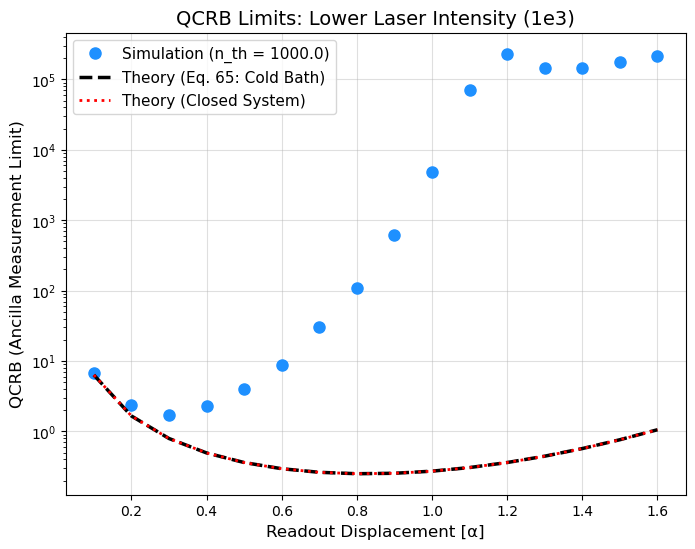

In [108]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e3, 1e-2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

In [109]:
using LinearAlgebra
using QuantumOptics
using IonSim

# Helper function to calculate Generalized Laguerre Polynomials L_n(x)
function laguerre(n::Int, x::Float64)
    if n == 0 return 1.0 end
    if n == 1 return 1.0 - x end
    L_prev2 = 1.0
    L_prev1 = 1.0 - x
    L_curr = 0.0
    for k in 1:(n-1)
        L_curr = ((2k + 1 - x) * L_prev1 - k * L_prev2) / (k + 1)
        L_prev2 = L_prev1
        L_prev1 = L_curr
    end
    return L_curr
end

function get_qcrb_coordinates(n_fock::Int=0, r_squeeze::Float64=0.0, laser_intensity::Float64=1e3, gamma_0::Float64=1e-2, n_th_set::Float64=1000.0)
    
    # ---------------------------------------------------------
    # 1. FIXED PARAMETERS & EXACT TIME CALCULATION
    # ---------------------------------------------------------
    beta_signal = 1.0
    d_beta = 1e-4 # Perturb the SIGNAL, not the readout!
    
    trap_freq = 19e5 
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))
    B_field = 1e-13
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    
    sim_mode = zmodes(trap_pre)[1]
    # Keep the 50 limit! It safely accommodates the anti-squeezed tails.
    sim_mode.N = 50
    sim_mode.shape = [51]
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    # EXACT TIME CALCULATION FOR BETA = 1.0
    t_sig_s = (2 * beta_signal) / (eta * Omega_eff)
    t_sig_us = t_sig_s * 1e6
    
    println("==================================================")
    println(" EXACT TIME CALCULATION")
    println("==================================================")
    println(" Signal Magnitude (β): ", beta_signal)
    println(" Exposure Time (t)   : ", round(t_sig_us, digits=2), " μs")
    println(" Base Gamma Rate     : ", gamma_0)
    println(" Thermal Phonons (n) : ", n_th_set)
    println("==================================================")

    # ---------------------------------------------------------
    # 2. GENERATE THE NOISY SIGNAL STATES (Base & Perturbed)
    # ---------------------------------------------------------
    b_fock = FockBasis(50) # Matching the expanded mode.N
    vac_qo = fockstate(b_fock, n_fock)
    
    if r_squeeze > 0.0
        squeeze_op = squeeze(b_fock, r_squeeze * exp(1im * 0.0))
        initial_m_qo = squeeze_op * vac_qo
    else
        initial_m_qo = vac_qo
    end
    
    initial_m_sim = Ket(sim_mode, initial_m_qo.data)
    initial_sys = normalize(ion["g"]) ⊗ initial_m_sim

    # CRITICAL FIX: β signal must be Imaginary (angle = pi/2) to span area against Real α
    println("\nRunning master equation for Base β Signal...")
    noisy_beta_state = SDF_apply_with_alpha(laser_intensity, pi/2, beta_signal, false, initial_sys, n_fock, n_th_set)
    
    println("\nRunning master equation for Perturbed β Signal (+ d_beta)...")
    noisy_beta_state_pert = SDF_apply_with_alpha(laser_intensity, pi/2, beta_signal + d_beta, false, initial_sys, n_fock, n_th_set)

    # ---------------------------------------------------------
    # 3. SWEEP ALPHA & GENERATE COORDINATES
    # ---------------------------------------------------------
    alphas = collect(0.1:0.1:1.6)
    sim_qcrbs = Float64[]
    theory_thermal_qcrbs = Float64[]
    theory_closed_qcrbs = Float64[]

    # Analytical Energy Decay Rate Γ
    Gamma_t = (gamma_0 * 1e-6) * t_sig_us

    println("\nSweeping α readout (generating coordinates)...")
    for a in alphas
        # --- A. SIMULATION ---
        # CRITICAL FIX: α readout must be Real (angle = 0.0) to benefit from the squeezed axis
        state_a_full = SDF_apply_with_alpha(laser_intensity, 0.0, a, true, noisy_beta_state, n_fock, n_th_set)
        state_a_pert_full = SDF_apply_with_alpha(laser_intensity, 0.0, a, true, noisy_beta_state_pert, n_fock, n_th_set)

        rho_spin_a = ptrace(state_a_full, 2)
        rho_spin_a_pert = ptrace(state_a_pert_full, 2)
        
        _, qcrb_sim = calculate_qcrb(rho_spin_a, rho_spin_a_pert, d_beta)
        push!(sim_qcrbs, qcrb_sim)

        # --- B. FULL THERMAL-SYSTEM THEORY ---
        thermal_heating_factor = (2 * n_th_set) + 1.0
        exp_term_open = 4 * a^2 * (thermal_heating_factor * (1 - exp(-Gamma_t)) + exp(-Gamma_t - 2*r_squeeze))
        numerator_open = exp(exp_term_open)
        
        L_val_open = laguerre(n_fock, 4 * a^2 * exp(-Gamma_t - 2*r_squeeze))
        denominator_open = 16 * a^2 * exp(-Gamma_t) * (L_val_open^2)
        
        push!(theory_thermal_qcrbs, numerator_open / denominator_open)

        # --- C. CLOSED-SYSTEM THEORY (Noiseless Baseline) ---
        exp_term_closed = 4 * a^2 * exp(-2*r_squeeze)
        numerator_closed = exp(exp_term_closed)
        
        L_val_closed = laguerre(n_fock, 4 * a^2 * exp(-2*r_squeeze))
        denominator_closed = 16 * a^2 * (L_val_closed^2)
        
        push!(theory_closed_qcrbs, numerator_closed / denominator_closed)
    end

    return alphas, sim_qcrbs, theory_thermal_qcrbs, theory_closed_qcrbs
end

get_qcrb_coordinates (generic function with 6 methods)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 0.01
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulati

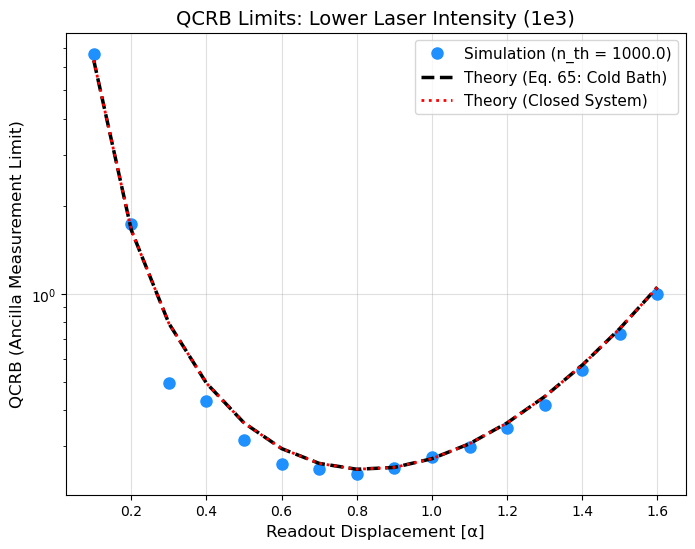

In [110]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e3, 1e-2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 1000.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simula

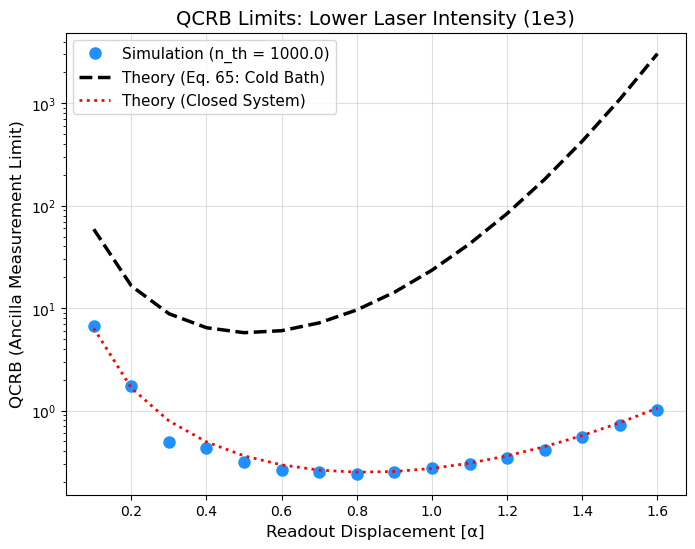

In [111]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e3, 1e3, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

In [112]:
using LinearAlgebra
using QuantumOptics
using IonSim

# Helper function to calculate Generalized Laguerre Polynomials L_n(x)
function laguerre(n::Int, x::Float64)
    if n == 0 return 1.0 end
    if n == 1 return 1.0 - x end
    L_prev2 = 1.0
    L_prev1 = 1.0 - x
    L_curr = 0.0
    for k in 1:(n-1)
        L_curr = ((2k + 1 - x) * L_prev1 - k * L_prev2) / (k + 1)
        L_prev2 = L_prev1
        L_prev1 = L_curr
    end
    return L_curr
end

# Added gamma_0_set to the function signature!
function SDF_apply_with_alpha(laser_intensity = 1e4, angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0, n_th_set = 10000.0, gamma_0_set = 1e-2)

    trap_freq = 19e5 
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] 
    mode_z.N = 50
    mode_z.shape = [51]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    B_field = 1e-13
    
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    mode = zmodes(trap_pre)[1]

    ψ_ion = normalize(ion["g"])
    ψ_mode = fockstate(mode, fock_state_n)
    
    ψ_initial = initial_state !== nothing ? initial_state : (ψ_ion ⊗ ψ_mode)

    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    
    red_angle = (π - 2*angle ) / 2
    blue_angle = red_angle + 2 * angle

    if (cat_state)
        red_angle = -angle
        blue_angle = angle
    end

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    trap_sdf = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
    h_sdf = hamiltonian(trap_sdf, timescale=1e-6, rwa_cutoff=Inf)
    
    tspan_sdf = collect(0:0.5:target_time_us)
    if tspan_sdf[end] < target_time_us
        push!(tspan_sdf, target_time_us)
    end

    if cat_state
        println("Simulating direct SDF for cat state creation...")
        if isa(ψ_initial, Operator)
            f_dyn_alpha(time_t, rho_state) = (h_sdf(time_t, rho_state), [], [])
            tout, sol = timeevolution.master_dynamic(tspan_sdf, ψ_initial, f_dyn_alpha)
            return sol[end]
        else
            tout, sol = timeevolution.schroedinger_dynamic(tspan_sdf, ψ_initial, h_sdf)
            return sol[end]
        end
    else
        I_spin = identityoperator(ion["g"].basis)  
        n_th = n_th_set           
        gamma_0 = gamma_0_set  # FIXED: Now strictly uses the function argument!
    
        gamma_plus_us = (gamma_0 * n_th) * 1e-6 
        gamma_minus_us = (gamma_0 * (n_th + 1)) * 1e-6 
        Gamma_eff_us = (gamma_plus_us + gamma_minus_us) / 2

        trap_active = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
        H_SDF_active = hamiltonian(trap_active, timescale=1e-6, rwa_cutoff=3e5)

        active_mode = zmodes(trap_active)[1]
        temp_fock_basis = FockBasis(active_mode.N) 
        a_op = DenseOperator(active_mode, active_mode, QuantumOptics.destroy(temp_fock_basis).data)
        at_op = DenseOperator(active_mode, active_mode, QuantumOptics.create(temp_fock_basis).data)

        a_sys = I_spin ⊗ a_op
        at_sys = I_spin ⊗ at_op

        J_cool = sqrt(gamma_minus_us) * a_sys
        J_heat = sqrt(gamma_plus_us) * at_sys
        J_ops = [J_cool, J_heat]
        J_ops_dag = dagger.(J_ops)

        function f_dyn(time_t, rho_state)
            return (H_SDF_active(time_t, rho_state), J_ops, J_ops_dag)
        end

        println("Simulating Carrier + SDF + Carrier sequence for Beta displacement...")
        
        Omega_carrier = Omega_eff * exp(-eta^2 / 2)
        t_pi_half_s = (π / 2) / Omega_carrier
        t_pi_half_us = t_pi_half_s * 1e6
        tspan_carrier = [0.0, t_pi_half_us]
        
        println("  -> Applying R(π/2) Carrier Pulse...")
        L_pi2 = Laser(Δ = 0, ϕ = π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_pi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_pi2])
        H_pi2_active = hamiltonian(trap_pi2, timescale=1e-6, rwa_cutoff=Inf)
        f_dyn_pi2(time_t, rho_state) = (H_pi2_active(time_t, rho_state), J_ops, J_ops_dag)
        
        rho_initial = isa(ψ_initial, Ket) ? dm(ψ_initial) : ψ_initial
        _, sol_pi2 = timeevolution.master_dynamic(tspan_carrier, rho_initial, f_dyn_pi2)
        ψ_after_pi2 = sol_pi2[end]

        println("  -> Applying SDF Displacement...")
        _, sol_sdf = timeevolution.master_dynamic(tspan_sdf, ψ_after_pi2, f_dyn)
        ψ_after_sdf = sol_sdf[end]

        println("  -> Applying R(-π/2) Carrier Pulse...")
        L_mpi2 = Laser(Δ = 0, ϕ = -π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_mpi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_mpi2])
        H_mpi2_active = hamiltonian(trap_mpi2, timescale=1e-6, rwa_cutoff=Inf)
        f_dyn_mpi2(time_t, rho_state) = (H_mpi2_active(time_t, rho_state), J_ops, J_ops_dag)
        _, sol_mpi2 = timeevolution.master_dynamic(tspan_carrier, ψ_after_sdf, f_dyn_mpi2)

        return sol_mpi2[end]
    end
end

function get_qcrb_coordinates(n_fock::Int=0, r_squeeze::Float64=0.0, laser_intensity::Float64=1e3, gamma_0::Float64=1e-2, n_th_set::Float64=1000.0)
    
    beta_signal = 1.0
    d_beta = 1e-4 
    
    trap_freq = 19e5 
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))
    B_field = 1e-13
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    
    sim_mode = zmodes(trap_pre)[1]
    sim_mode.N = 50
    sim_mode.shape = [51]
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    t_sig_s = (2 * beta_signal) / (eta * Omega_eff)
    t_sig_us = t_sig_s * 1e6
    
    println("==================================================")
    println(" EXACT TIME CALCULATION")
    println("==================================================")
    println(" Signal Magnitude (β): ", beta_signal)
    println(" Exposure Time (t)   : ", round(t_sig_us, digits=2), " μs")
    println(" Base Gamma Rate     : ", gamma_0)
    println(" Thermal Phonons (n) : ", n_th_set)
    println("==================================================")

    b_fock = FockBasis(50) 
    vac_qo = fockstate(b_fock, n_fock)
    
    if r_squeeze > 0.0
        squeeze_op = squeeze(b_fock, r_squeeze * exp(1im * 0.0))
        initial_m_qo = squeeze_op * vac_qo
    else
        initial_m_qo = vac_qo
    end
    
    initial_m_sim = Ket(sim_mode, initial_m_qo.data)
    initial_sys = normalize(ion["g"]) ⊗ initial_m_sim

    println("\nRunning master equation for Base β Signal...")
    # Passed gamma_0 into the generator
    noisy_beta_state = SDF_apply_with_alpha(laser_intensity, pi/2, beta_signal, false, initial_sys, n_fock, n_th_set, gamma_0)
    
    println("\nRunning master equation for Perturbed β Signal (+ d_beta)...")
    # Passed gamma_0 into the generator
    noisy_beta_state_pert = SDF_apply_with_alpha(laser_intensity, pi/2, beta_signal + d_beta, false, initial_sys, n_fock, n_th_set, gamma_0)

    alphas = collect(0.1:0.1:1.6)
    sim_qcrbs = Float64[]
    theory_thermal_qcrbs = Float64[]
    theory_closed_qcrbs = Float64[]

    Gamma_t = (gamma_0 * 1e-6) * t_sig_us

    println("\nSweeping α readout (generating coordinates)...")
    for a in alphas
        # Passed gamma_0 into the readout
        state_a_full = SDF_apply_with_alpha(laser_intensity, 0.0, a, true, noisy_beta_state, n_fock, n_th_set, gamma_0)
        state_a_pert_full = SDF_apply_with_alpha(laser_intensity, 0.0, a, true, noisy_beta_state_pert, n_fock, n_th_set, gamma_0)

        rho_spin_a = ptrace(state_a_full, 2)
        rho_spin_a_pert = ptrace(state_a_pert_full, 2)
        
        _, qcrb_sim = calculate_qcrb(rho_spin_a, rho_spin_a_pert, d_beta)
        push!(sim_qcrbs, qcrb_sim)

        thermal_heating_factor = (2 * n_th_set) + 1.0
        exp_term_open = 4 * a^2 * (thermal_heating_factor * (1 - exp(-Gamma_t)) + exp(-Gamma_t - 2*r_squeeze))
        numerator_open = exp(exp_term_open)
        
        L_val_open = laguerre(n_fock, 4 * a^2 * exp(-Gamma_t - 2*r_squeeze))
        denominator_open = 16 * a^2 * exp(-Gamma_t) * (L_val_open^2)
        
        push!(theory_thermal_qcrbs, numerator_open / denominator_open)

        exp_term_closed = 4 * a^2 * exp(-2*r_squeeze)
        numerator_closed = exp(exp_term_closed)
        
        L_val_closed = laguerre(n_fock, 4 * a^2 * exp(-2*r_squeeze))
        denominator_closed = 16 * a^2 * (L_val_closed^2)
        
        push!(theory_closed_qcrbs, numerator_closed / denominator_closed)
    end

    return alphas, sim_qcrbs, theory_thermal_qcrbs, theory_closed_qcrbs
end

get_qcrb_coordinates (generic function with 6 methods)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 1000.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simula

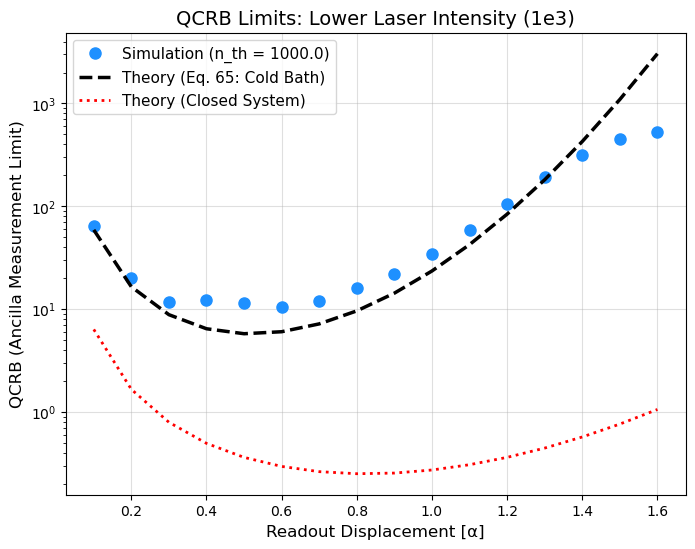

In [113]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e3, 1e3, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulating direct SDF for cat state creation...
Simulat

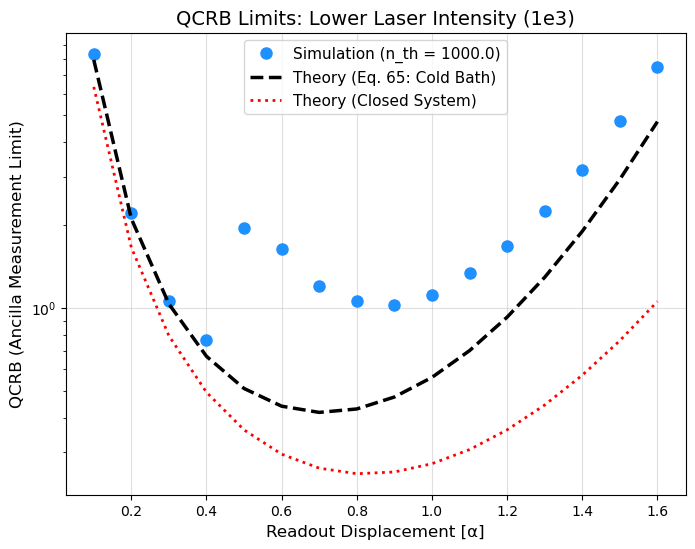

In [115]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e3, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

In [118]:
function SDF_apply_with_alpha(laser_intensity = 1e4, angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0, n_th_set = 10000.0, gamma_0_set = 1e-2)

    # ---------------------------------------------------------
    # 1. Common Trap Initialization
    # ---------------------------------------------------------
    trap_freq = 19e5 
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    # Keep N=50 to prevent boundary collisions with squeezed tails
    mode_z = zmodes(chain)[1] 
    mode_z.N = 50
    mode_z.shape = [51]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    B_field = 1e-13
    
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    mode = zmodes(trap_pre)[1]

    ψ_ion = normalize(ion["g"])
    ψ_mode = fockstate(mode, fock_state_n)
    
    ψ_initial = initial_state !== nothing ? initial_state : (ψ_ion ⊗ ψ_mode)

    # ---------------------------------------------------------
    # 2. Physics & Dynamic Time Calculation
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    
    # CRITICAL FIX: Guarantee a pure X-Force by making the phase sum 0
    red_angle = -angle
    blue_angle = angle

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    trap_sdf = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
    
    tspan_sdf = collect(0:0.5:target_time_us)
    if tspan_sdf[end] < target_time_us
        push!(tspan_sdf, target_time_us)
    end

    # ---------------------------------------------------------
    # 3. SEQUENCE EXECUTION
    # ---------------------------------------------------------
    if cat_state
        # PERFECT OPERATOR MATH: No time-evolution solver, no readout noise.
        println("Applying ideal Operator Math for cat state creation (No readout noise)...")
        
        alpha_complex = target_alpha * exp(1im * angle)
        g = ion["g"]
        e = ion["e"]
        
        # 1. Create the X-basis spin eigenstates (|+> and |->)
        x_plus = normalize(g + e)
        x_minus = normalize(g - e)
        
        # 2. Create the spin projection operators
        P_plus = x_plus ⊗ dagger(x_plus)
        P_minus = x_minus ⊗ dagger(x_minus)
        
        # 3. Create the perfect geometric displacements
        D_plus = IonSim.displace(mode, alpha_complex)
        D_minus = IonSim.displace(mode, -alpha_complex)
        
        # 4. Construct the ideal Entangling Unitary
        U_SDF = (P_plus ⊗ D_plus) + (P_minus ⊗ D_minus)
        
        # 5. Evolve the state perfectly
        if isa(ψ_initial, Operator)
            # Mixed state evolution: U * ρ * U^†
            return U_SDF * ψ_initial * dagger(U_SDF)
        else
            # Pure state evolution: U * |ψ>
            return U_SDF * ψ_initial
        end
        
    else
        # NOISY TIME-EVOLUTION: Master equation strictly for Beta Signal
        I_spin = identityoperator(ion["g"].basis)  
        n_th = n_th_set           
        gamma_0 = gamma_0_set  
    
        gamma_plus_us = (gamma_0 * n_th) * 1e-6 
        gamma_minus_us = (gamma_0 * (n_th + 1)) * 1e-6 
        Gamma_eff_us = (gamma_plus_us + gamma_minus_us) / 2

        trap_active = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
        H_SDF_active = hamiltonian(trap_active, timescale=1e-6, rwa_cutoff=3e5)

        active_mode = zmodes(trap_active)[1]
        temp_fock_basis = FockBasis(active_mode.N) 
        a_op = DenseOperator(active_mode, active_mode, QuantumOptics.destroy(temp_fock_basis).data)
        at_op = DenseOperator(active_mode, active_mode, QuantumOptics.create(temp_fock_basis).data)

        a_sys = I_spin ⊗ a_op
        at_sys = I_spin ⊗ at_op

        J_cool = sqrt(gamma_minus_us) * a_sys
        J_heat = sqrt(gamma_plus_us) * at_sys
        J_ops = [J_cool, J_heat]
        J_ops_dag = dagger.(J_ops)

        function f_dyn(time_t, rho_state)
            return (H_SDF_active(time_t, rho_state), J_ops, J_ops_dag)
        end

        println("Simulating Carrier + SDF + Carrier sequence for Beta displacement (with noise)...")
        
        Omega_carrier = Omega_eff * exp(-eta^2 / 2)
        t_pi_half_s = (π / 2) / Omega_carrier
        t_pi_half_us = t_pi_half_s * 1e6
        tspan_carrier = [0.0, t_pi_half_us]
        
        println("  -> Applying R(π/2) Carrier Pulse...")
        L_pi2 = Laser(Δ = 0, ϕ = π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_pi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_pi2])
        H_pi2_active = hamiltonian(trap_pi2, timescale=1e-6, rwa_cutoff=Inf)
        f_dyn_pi2(time_t, rho_state) = (H_pi2_active(time_t, rho_state), J_ops, J_ops_dag)
        
        rho_initial = isa(ψ_initial, Ket) ? dm(ψ_initial) : ψ_initial
        _, sol_pi2 = timeevolution.master_dynamic(tspan_carrier, rho_initial, f_dyn_pi2)
        ψ_after_pi2 = sol_pi2[end]

        println("  -> Applying SDF Displacement...")
        _, sol_sdf = timeevolution.master_dynamic(tspan_sdf, ψ_after_pi2, f_dyn)
        ψ_after_sdf = sol_sdf[end]

        println("  -> Applying R(-π/2) Carrier Pulse...")
        L_mpi2 = Laser(Δ = 0, ϕ = -π/2, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
        trap_mpi2 = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_mpi2])
        H_mpi2_active = hamiltonian(trap_mpi2, timescale=1e-6, rwa_cutoff=Inf)
        f_dyn_mpi2(time_t, rho_state) = (H_mpi2_active(time_t, rho_state), J_ops, J_ops_dag)
        _, sol_mpi2 = timeevolution.master_dynamic(tspan_carrier, ψ_after_sdf, f_dyn_mpi2)

        return sol_mpi2[end]
    end
end

SDF_apply_with_alpha (generic function with 9 methods)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating Carrier + SDF + Carrier sequence for Beta displacement (with noise)...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating Carrier + SDF + Carrier sequence for Beta displacement (with noise)...
  -> Applying R(π/2) Carrier Pulse...
  -> Applying SDF Displacement...
  -> Applying R(-π/2) Carrier Pulse...

Sweeping α readout (generating coordinates)...
Applying ideal Operator Math for cat state creation (No readout noise)...
Applying ideal Operator Math for cat state creation (No readout noise)...
Applying ideal Operator Math for cat state creation (No readout noise)...
Applying ideal Operator Math for cat state creation (No readout noise)...
Applying ideal Operat

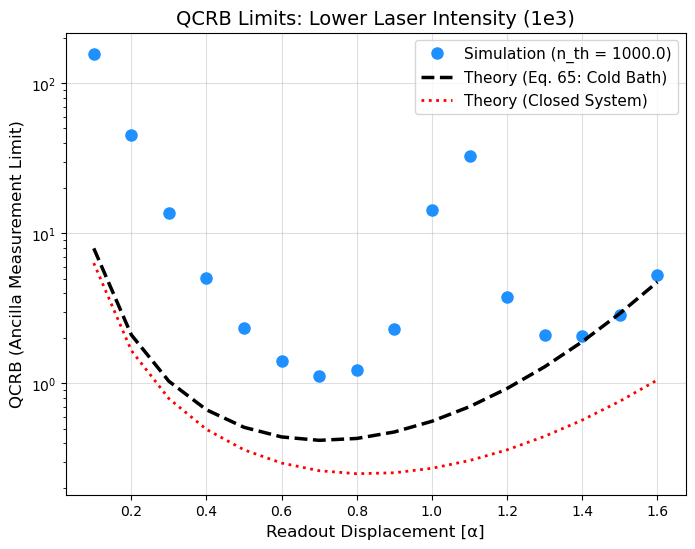

In [119]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e3, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

In [120]:
function SDF_apply_with_alpha(laser_intensity = 1e4, angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0, n_th_set = 10000.0, gamma_0_set = 1e-2)

    # ---------------------------------------------------------
    # 1. Common Trap Initialization
    # ---------------------------------------------------------
    trap_freq = 19e5 
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    # Keep N=50 to prevent boundary collisions with squeezed tails
    mode_z = zmodes(chain)[1] 
    mode_z.N = 50
    mode_z.shape = [51]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    B_field = 1e-13
    
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    mode = zmodes(trap_pre)[1]

    ψ_ion = normalize(ion["g"])
    ψ_mode = fockstate(mode, fock_state_n)
    
    ψ_initial = initial_state !== nothing ? initial_state : (ψ_ion ⊗ ψ_mode)

    # ---------------------------------------------------------
    # 2. Physics & Dynamic Time Calculation
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    # Calculate physical operation time based on the laser intensity
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6

    # ---------------------------------------------------------
    # 3. SEQUENCE EXECUTION
    # ---------------------------------------------------------
    if cat_state
        # =========================================================
        # PERFECT OPERATOR MATH: Alpha Readout (No readout noise)
        # =========================================================
        alpha_complex = target_alpha * exp(1im * angle)
        g = ion["g"]
        e = ion["e"]
        
        # 1. Create the X-basis spin eigenstates (|+> and |->)
        x_plus = normalize(g + e)
        x_minus = normalize(g - e)
        
        # 2. Create the spin projection operators
        P_plus = x_plus ⊗ dagger(x_plus)
        P_minus = x_minus ⊗ dagger(x_minus)
        
        # 3. Create the perfect geometric displacements
        D_plus = IonSim.displace(mode, alpha_complex)
        D_minus = IonSim.displace(mode, -alpha_complex)
        
        # 4. Construct the ideal Entangling Unitary
        U_SDF = (P_plus ⊗ D_plus) + (P_minus ⊗ D_minus)
        
        # 5. Evolve the state perfectly
        if isa(ψ_initial, Operator)
            return U_SDF * ψ_initial * dagger(U_SDF)
        else
            return U_SDF * ψ_initial
        end
        
    else
        # =========================================================
        # CONTINUOUS LINDBLAD DISPLACEMENT: Beta Signal (With Noise)
        # =========================================================
        I_spin = identityoperator(ion["g"].basis)  
        n_th = n_th_set           
        gamma_0 = gamma_0_set  
    
        gamma_plus_us = (gamma_0 * n_th) * 1e-6 
        gamma_minus_us = (gamma_0 * (n_th + 1)) * 1e-6 

        # Extract compatible creation/annihilation operators
        temp_fock_basis = FockBasis(mode.N) 
        a_op = DenseOperator(mode, mode, QuantumOptics.destroy(temp_fock_basis).data)
        at_op = DenseOperator(mode, mode, QuantumOptics.create(temp_fock_basis).data)

        # EXACT ANALYTICAL HAMILTONIAN FOR CONTINUOUS DISPLACEMENT
        # H = (i * r / t) * (exp(iθ) * a^dag - exp(-iθ) * a)
        H_m = (1im * target_alpha / target_time_us) * (exp(1im * angle) * at_op - exp(-1im * angle) * a_op)
        H_sys = I_spin ⊗ H_m

        # Build Lindblad Jump Operators
        a_sys = I_spin ⊗ a_op
        at_sys = I_spin ⊗ at_op

        J_cool = sqrt(gamma_minus_us) * a_sys
        J_heat = sqrt(gamma_plus_us) * at_sys
        J_ops = [J_cool, J_heat]
        J_ops_dag = dagger.(J_ops)

        function f_dyn(time_t, rho_state)
            return (H_sys, J_ops, J_ops_dag)
        end

        rho_initial = isa(ψ_initial, Ket) ? dm(ψ_initial) : ψ_initial
        tspan_sdf = collect(0:0.5:target_time_us)
        if tspan_sdf[end] < target_time_us
            push!(tspan_sdf, target_time_us)
        end

        println("Simulating pure continuous Beta displacement with Lindblad noise...")
        _, sol_beta = timeevolution.master_dynamic(tspan_sdf, rho_initial, f_dyn)

        return sol_beta[end]
    end
end

SDF_apply_with_alpha (generic function with 9 methods)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


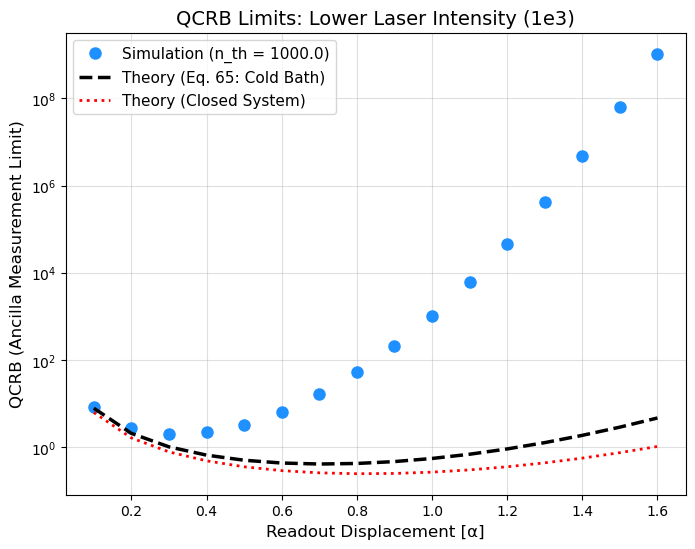

In [121]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e3, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

In [124]:
function SDF_apply_with_alpha(laser_intensity = 1e4, angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0, n_th_set = 10000.0, gamma_0_set = 1e-2)

    # ---------------------------------------------------------
    # 1. Common Trap Initialization
    # ---------------------------------------------------------
    trap_freq = 19e5 
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] 
    mode_z.N = 50
    mode_z.shape = [51]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    B_field = 1e-13
    
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    mode = zmodes(trap_pre)[1]

    ψ_ion = normalize(ion["g"])
    ψ_mode = fockstate(mode, fock_state_n)
    
    ψ_initial = initial_state !== nothing ? initial_state : (ψ_ion ⊗ ψ_mode)

    # ---------------------------------------------------------
    # 2. Physics Calculation
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π

    # ---------------------------------------------------------
    # 3. SEQUENCE EXECUTION
    # ---------------------------------------------------------
    if cat_state
        # =========================================================
        # PERFECT OPERATOR MATH: Alpha Readout (No readout noise)
        # =========================================================
        alpha_complex = target_alpha * exp(1im * angle)
        g = ion["g"]
        e = ion["e"]
        
        x_plus = normalize(g + e)
        x_minus = normalize(g - e)
        
        P_plus = x_plus ⊗ dagger(x_plus)
        P_minus = x_minus ⊗ dagger(x_minus)
        
        D_plus = IonSim.displace(mode, alpha_complex)
        D_minus = IonSim.displace(mode, -alpha_complex)
        
        U_SDF = (P_plus ⊗ D_plus) + (P_minus ⊗ D_minus)
        
        if isa(ψ_initial, Operator)
            return U_SDF * ψ_initial * dagger(U_SDF)
        else
            return U_SDF * ψ_initial
        end
        
    else
        # =========================================================
        # CONTINUOUS LINDBLAD DISPLACEMENT: Beta Signal (With Noise)
        # =========================================================
        I_spin = identityoperator(ion["g"].basis)  
        n_th = n_th_set           
        gamma_0 = gamma_0_set  
    
        gamma_plus_us = (gamma_0 * n_th) * 1e-6 
        gamma_minus_us = (gamma_0 * (n_th + 1)) * 1e-6 

        temp_fock_basis = FockBasis(mode.N) 
        a_op = DenseOperator(mode, mode, QuantumOptics.destroy(temp_fock_basis).data)
        at_op = DenseOperator(mode, mode, QuantumOptics.create(temp_fock_basis).data)

        # CRITICAL FIX: Lock the simulation time to the beta=1.0 baseline.
        # This guarantees identical ODE grid steps for finite difference.
        baseline_beta = 1.0 
        target_time_s = (2 * baseline_beta) / (eta * Omega_eff)
        target_time_us = target_time_s * 1e6

        # The target_alpha (beta + d_beta) now scales the Hamiltonian amplitude!
        H_m = (1im * target_alpha / target_time_us) * (exp(1im * angle) * at_op - exp(-1im * angle) * a_op)
        H_sys = I_spin ⊗ H_m

        a_sys = I_spin ⊗ a_op
        at_sys = I_spin ⊗ at_op

        J_cool = sqrt(gamma_minus_us) * a_sys
        J_heat = sqrt(gamma_plus_us) * at_sys
        J_ops = [J_cool, J_heat]
        J_ops_dag = dagger.(J_ops)

        function f_dyn(time_t, rho_state)
            return (H_sys, J_ops, J_ops_dag)
        end

        rho_initial = isa(ψ_initial, Ket) ? dm(ψ_initial) : ψ_initial
        
        # We only need the start and end points for the solver now
        tspan_sdf = [0.0, target_time_us]

        println("Simulating pure continuous Beta displacement with Lindblad noise...")
        # Added strict tolerances to completely eliminate numerical ODE phase drift
        _, sol_beta = timeevolution.master_dynamic(tspan_sdf, rho_initial, f_dyn, reltol=1e-10, abstol=1e-12)

        return sol_beta[end]
    end
end

SDF_apply_with_alpha (generic function with 9 methods)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


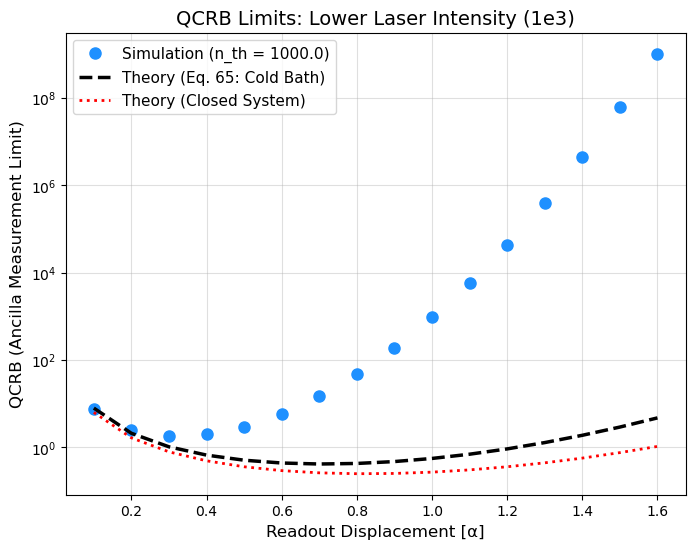

In [125]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e3, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

In [127]:

function get_qcrb_coordinates(n_fock::Int=0, r_squeeze::Float64=0.0, laser_intensity::Float64=1e3, gamma_0::Float64=1e-2, n_th_set::Float64=1000.0)
    
    beta_signal = 1.0
    d_beta = 1e-4 
    
    trap_freq = 19e5 
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))
    B_field = 1e-13
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    
    sim_mode = zmodes(trap_pre)[1]
    sim_mode.N = 50
    sim_mode.shape = [51]
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    t_sig_s = (2 * beta_signal) / (eta * Omega_eff)
    t_sig_us = t_sig_s * 1e6
    
    println("==================================================")
    println(" EXACT TIME CALCULATION")
    println("==================================================")
    println(" Signal Magnitude (β): ", beta_signal)
    println(" Exposure Time (t)   : ", round(t_sig_us, digits=2), " μs")
    println(" Base Gamma Rate     : ", gamma_0)
    println(" Thermal Phonons (n) : ", n_th_set)
    println("==================================================")

    b_fock = FockBasis(50) 
    vac_qo = fockstate(b_fock, n_fock)
    
    if r_squeeze > 0.0
        squeeze_op = squeeze(b_fock, r_squeeze * exp(1im * 0.0))
        initial_m_qo = squeeze_op * vac_qo
    else
        initial_m_qo = vac_qo
    end
    
    initial_m_sim = Ket(sim_mode, initial_m_qo.data)
    initial_sys = normalize(ion["g"]) ⊗ initial_m_sim

    println("\nRunning master equation for Base β Signal...")
    # Passed gamma_0 into the generator
    noisy_beta_state = SDF_apply_with_alpha(laser_intensity, 0.0, beta_signal, false, initial_sys, n_fock, n_th_set, gamma_0)
    
    println("\nRunning master equation for Perturbed β Signal (+ d_beta)...")
    # Passed gamma_0 into the generator
    noisy_beta_state_pert = SDF_apply_with_alpha(laser_intensity, 0.0, beta_signal + d_beta, false, initial_sys, n_fock, n_th_set, gamma_0)

    alphas = collect(0.1:0.1:1.6)
    sim_qcrbs = Float64[]
    theory_thermal_qcrbs = Float64[]
    theory_closed_qcrbs = Float64[]

    Gamma_t = (gamma_0 * 1e-6) * t_sig_us

    println("\nSweeping α readout (generating coordinates)...")
    for a in alphas
        # Passed gamma_0 into the readout
        state_a_full = SDF_apply_with_alpha(laser_intensity, pi/2, a, true, noisy_beta_state, n_fock, n_th_set, gamma_0)
        state_a_pert_full = SDF_apply_with_alpha(laser_intensity, pi/2, a, true, noisy_beta_state_pert, n_fock, n_th_set, gamma_0)

        rho_spin_a = ptrace(state_a_full, 2)
        rho_spin_a_pert = ptrace(state_a_pert_full, 2)
        
        _, qcrb_sim = calculate_qcrb(rho_spin_a, rho_spin_a_pert, d_beta)
        push!(sim_qcrbs, qcrb_sim)

        thermal_heating_factor = (2 * n_th_set) + 1.0
        exp_term_open = 4 * a^2 * (thermal_heating_factor * (1 - exp(-Gamma_t)) + exp(-Gamma_t - 2*r_squeeze))
        numerator_open = exp(exp_term_open)
        
        L_val_open = laguerre(n_fock, 4 * a^2 * exp(-Gamma_t - 2*r_squeeze))
        denominator_open = 16 * a^2 * exp(-Gamma_t) * (L_val_open^2)
        
        push!(theory_thermal_qcrbs, numerator_open / denominator_open)

        exp_term_closed = 4 * a^2 * exp(-2*r_squeeze)
        numerator_closed = exp(exp_term_closed)
        
        L_val_closed = laguerre(n_fock, 4 * a^2 * exp(-2*r_squeeze))
        denominator_closed = 16 * a^2 * (L_val_closed^2)
        
        push!(theory_closed_qcrbs, numerator_closed / denominator_closed)
    end

    return alphas, sim_qcrbs, theory_thermal_qcrbs, theory_closed_qcrbs
end

get_qcrb_coordinates (generic function with 6 methods)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


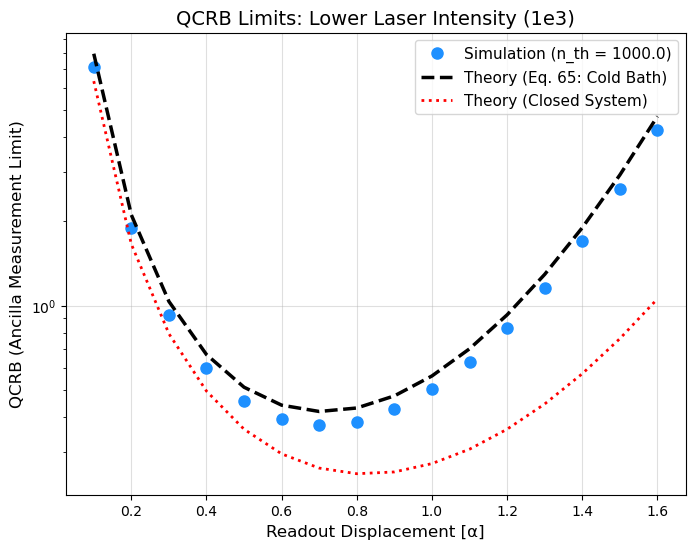

In [128]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e3, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


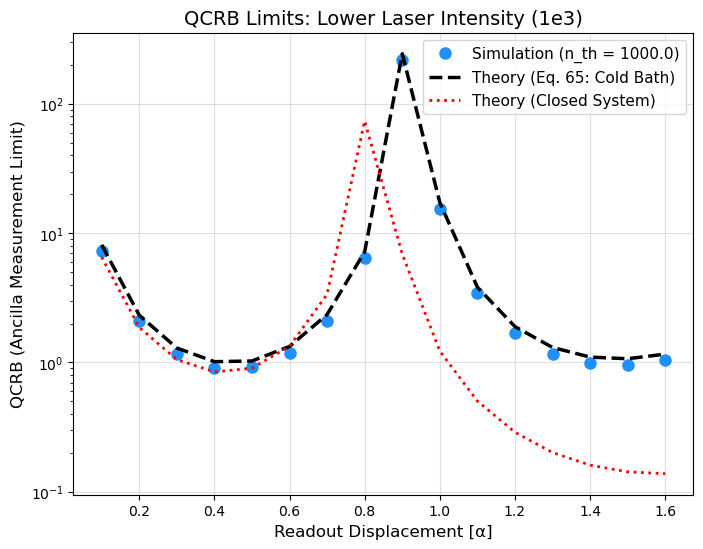

In [129]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(1, 0.5, 1e3, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 697.81 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


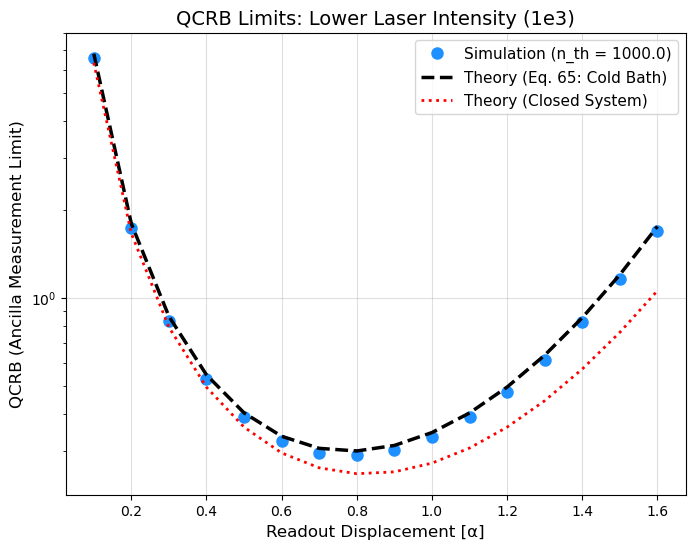

In [130]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e4, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 220.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


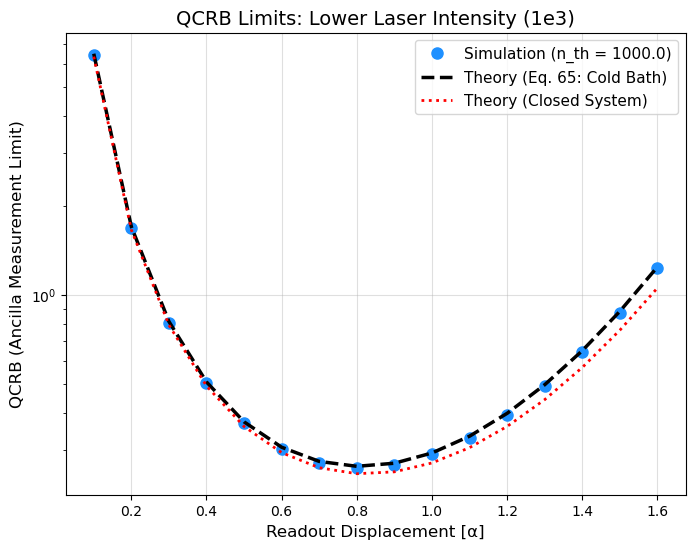

In [131]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e5, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


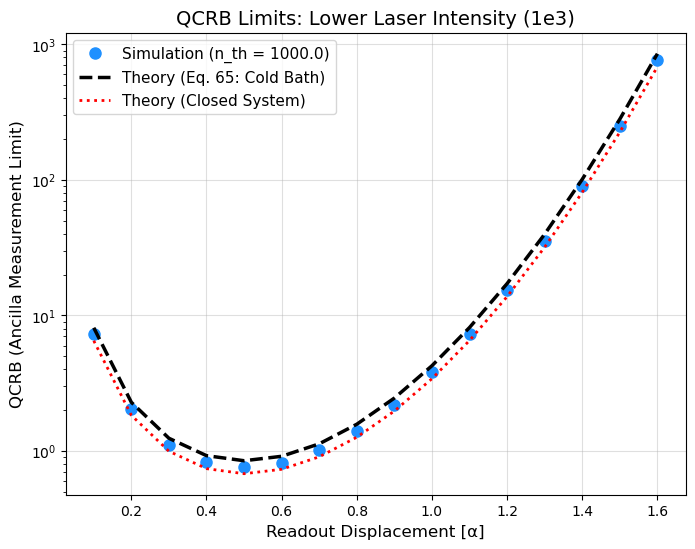

In [132]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.0, 1e3, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


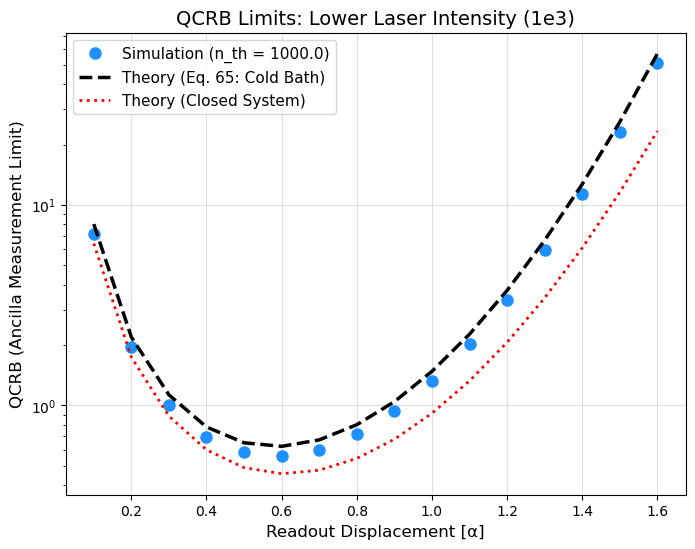

In [133]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.2, 1e3, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 1000.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


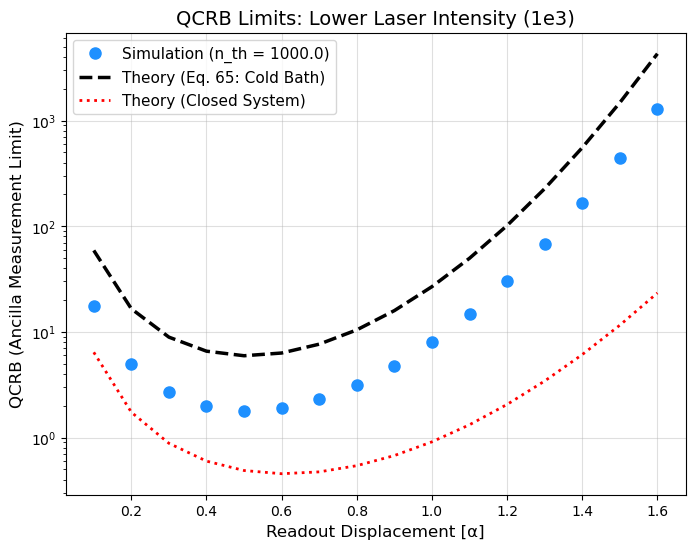

In [134]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.2, 1e3, 1e3, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 10.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


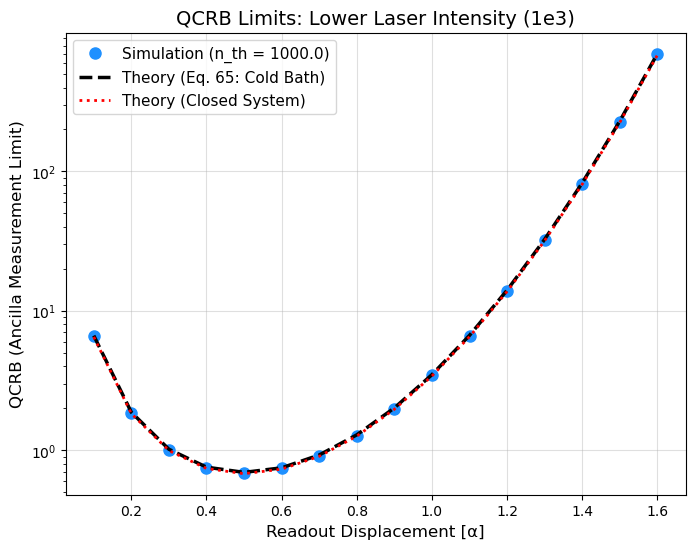

In [135]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.0, 1e3, 1e1, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 10.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


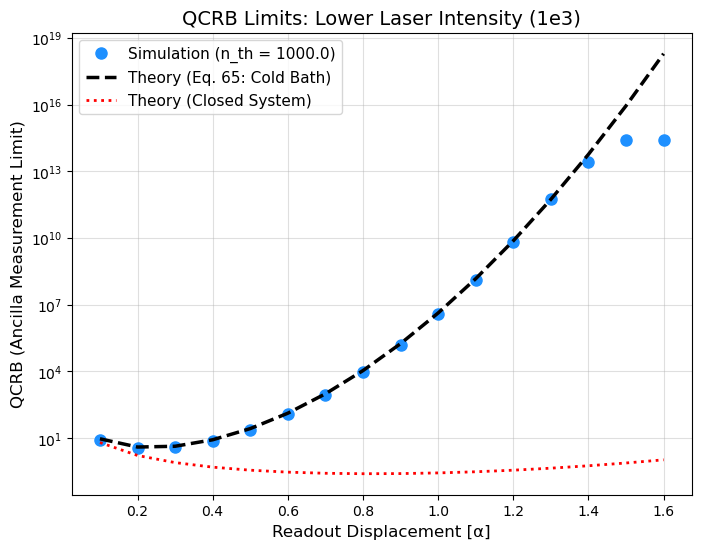

In [140]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e3, 1e2, 10.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


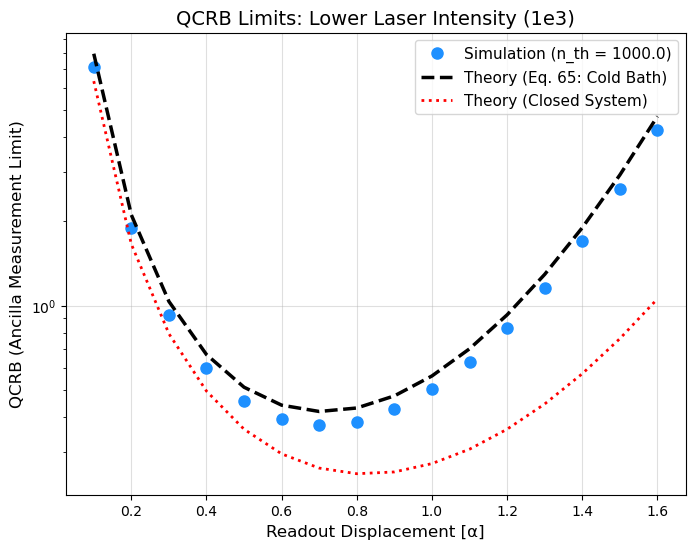

In [141]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 0.5, 1e3, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


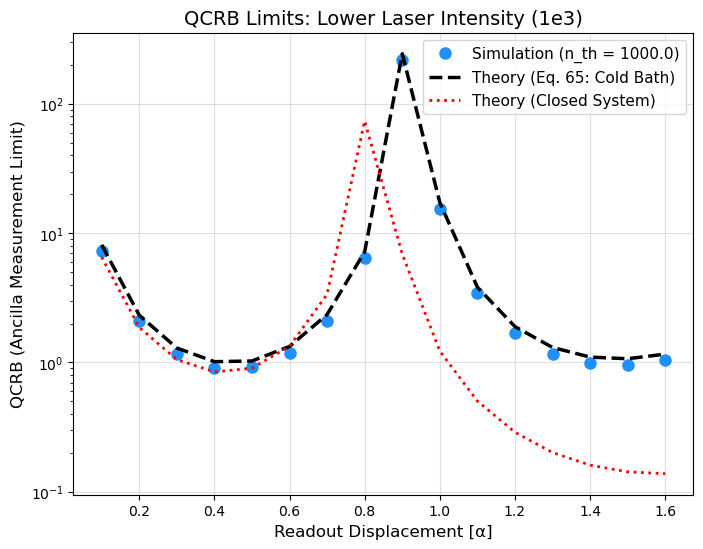

In [143]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(1, 0.5, 1e3, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


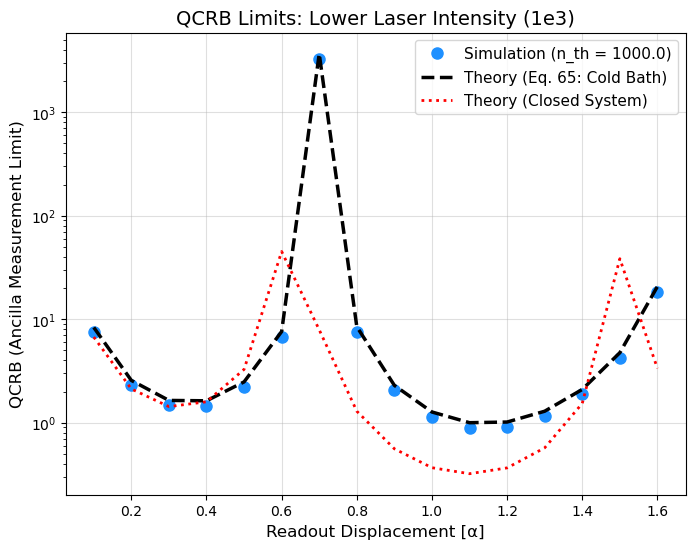

In [145]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(2, 0.5, 1e3, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


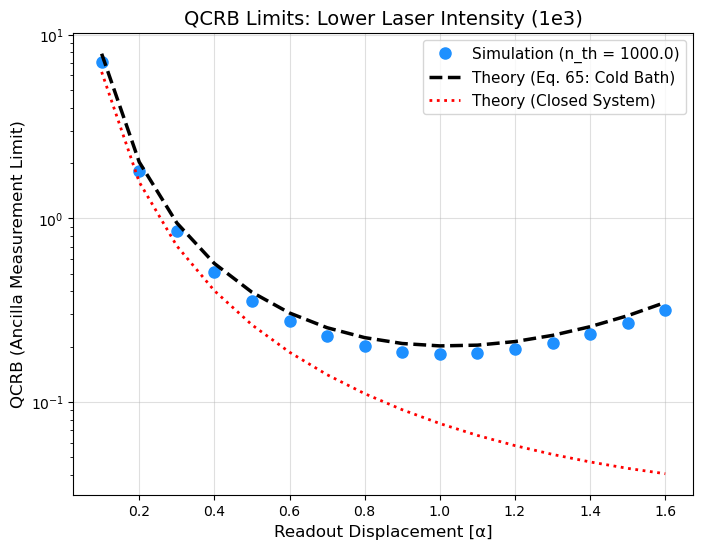

In [146]:
# 1. Get the coordinates for your exact parameters
# (n_fock=0, r_squeeze=0.0, laser_intensity=1e3, gamma=1e-2, n_th=1000.0)
x_alpha, y_sim, y_theory_open, y_theory_closed = get_qcrb_coordinates(0, 1.5, 1e3, 1e2, 0.0)

# 2. Create the custom plot
fig = figure(figsize=(8, 6))

# Simulated Data
plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = 1000.0)")

# Open-System Theory (Eq. 65)
plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")

# Closed-System Baseline (No Noise)
plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Closed System)")

yscale("log")
xlabel("Readout Displacement [α]", fontsize=12)
ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
title("QCRB Limits: Lower Laser Intensity (1e3)", fontsize=14)
legend(fontsize=11)
grid(alpha=0.4)

display(fig)